In [1]:
import os
import json
import copy
import math
import random
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from joblib import dump, load
import hashlib

import textwrap
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from IPython.display import display

from sklearn.decomposition import PCA as CPU_PCA

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor

USE_GPU_ACCEL = False
GPU_ACCEL_ACTIVE = False
CUML_ACCEL_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# Seeds
BASE_SEED = 19537
ALL_SEEDS = [19537, 1584678, 17052356]

SEED = BASE_SEED
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.manual_seed(SEED)


def set_seeds(seed: int) -> None:
    global SEED, RNG
    SEED = int(seed)
    random.seed(SEED)
    np.random.seed(SEED)
    RNG = np.random.default_rng(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings(
    "ignore",
    message=r".*sklearn\.utils\.parallel\.delayed.*sklearn\.utils\.parallel\.Parallel.*",
    category=UserWarning,
)

# Paths
ARTEFACTS = Path("artefacts")
IN_CLEAN = ARTEFACTS / "cleaned" / "notebook 2"
IN_T2 = ARTEFACTS / "aligned" / "notebook 1" / "track2_nonintersection"
IN_META = ARTEFACTS / "metadata"

NOTEBOOK_SUBDIR = "notebook 5"
OUT_REPORTS = ARTEFACTS / "reports" / NOTEBOOK_SUBDIR
OUT_META = ARTEFACTS / "metadata" / NOTEBOOK_SUBDIR
OUT_CACHE = ARTEFACTS / "cache" / NOTEBOOK_SUBDIR

for d in [OUT_REPORTS, OUT_META, OUT_CACHE]:
    d.mkdir(parents=True, exist_ok=True)

# Device
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch device: {TORCH_DEVICE}")

# Load backbone lock
LOCK_PATH = IN_META / "proteomics_backbone_lock.json"
if not LOCK_PATH.exists():
    raise FileNotFoundError(
        f"proteomics_backbone_lock.json not found at {LOCK_PATH}. "
        "Run the lock cell at the end of Notebook 3b first."
    )
with LOCK_PATH.open("r") as f:
    backbone_lock = json.load(f)

PRIMARY_ARM = backbone_lock["track1_primary_arm"]
SECONDARY_ARM = backbone_lock["track1_secondary_arm"]
TRACK2_ARM = backbone_lock["track2_stress_test_arm"]

print("Backbone lock loaded.")
print(f"  Primary arm  : {PRIMARY_ARM}")
print(f"  Secondary arm: {SECONDARY_ARM}")
print(f"  Track 2 arm  : {TRACK2_ARM}")
print(f"  Seeds to run : {ALL_SEEDS}")

ACTIVE_ARMS = [
    "prot_combined_union",
    "prot_procan_depmapSanger",
    "prot_rppa_ccle",
    "prot_ms_ccle_gygi",
]
# Full 4-modality lattice
FULL_FEATURE_SETS = [
    "rna",
    "cnv",
    "mut",
    "prot",
    "rna+cnv",
    "rna+mut",
    "rna+prot",
    "cnv+mut",
    "cnv+prot",
    "mut+prot",
    "rna+cnv+mut",
    "rna+cnv+prot",
    "rna+mut+prot",
    "cnv+mut+prot",
    "rna+cnv+mut+prot",
]

PROT_FEATURE_SETS = FULL_FEATURE_SETS.copy()

ACTIVE_MODELS = ["elasticnet", "ridge", "extratrees"]

PROT_TEST_CONFIGS = [
    {"rank": rank, "arm": arm, "model": model, "feature_set": fs}
    for rank, (arm, model, fs) in enumerate(
        [
            (arm, model, fs)
            for arm in ACTIVE_ARMS
            for model in ACTIVE_MODELS
            for fs in PROT_FEATURE_SETS
        ],
        start=1,
    )
]

CONFIGS_BY_ARM = {
    arm: [cfg for cfg in PROT_TEST_CONFIGS if cfg["arm"] == arm]
    for arm in ACTIVE_ARMS
}

# For CNV sensitivity, test every config that contains CNV
CNV_FEATURE_SETS = [fs for fs in FULL_FEATURE_SETS if "cnv" in fs.split("+")]

CNV_TEST_CONFIGS = [
    {"rank": 1000 + rank, "arm": arm, "model": model, "feature_set": fs}
    for rank, (arm, model, fs) in enumerate(
        [
            (arm, model, fs)
            for arm in ACTIVE_ARMS
            for model in ACTIVE_MODELS
            for fs in CNV_FEATURE_SETS
        ],
        start=0,
    )
]

CNV_CONFIGS_BY_ARM = {
    arm: [cfg for cfg in CNV_TEST_CONFIGS if cfg["arm"] == arm]
    for arm in ACTIVE_ARMS
}

EXPECTED_PROT_CONFIG_KEYS = {
    (int(cfg["rank"]), str(cfg["arm"]), str(cfg["model"]).lower(), str(cfg["feature_set"]))
    for cfg in PROT_TEST_CONFIGS
}

EXPECTED_PROT_CONFIG_KEYS_BY_ARM = {
    arm: {
        (int(cfg["rank"]), str(cfg["arm"]), str(cfg["model"]).lower(), str(cfg["feature_set"]))
        for cfg in cfgs
    }
    for arm, cfgs in CONFIGS_BY_ARM.items()
}

EXPECTED_CNV_CONFIG_KEYS = {
    (int(cfg["rank"]), str(cfg["arm"]), str(cfg["model"]).lower(), str(cfg["feature_set"]))
    for cfg in CNV_TEST_CONFIGS
}

EXPECTED_CNV_CONFIG_KEYS_BY_ARM = {
    arm: {
        (int(cfg["rank"]), str(cfg["arm"]), str(cfg["model"]).lower(), str(cfg["feature_set"]))
        for cfg in cfgs
    }
    for arm, cfgs in CNV_CONFIGS_BY_ARM.items()
}

def checkpoint_matches_expected_grid(df: pd.DataFrame, expected_keys) -> bool:
    needed = {"config_rank", "arm", "model", "feature_set"}
    if not needed.issubset(df.columns):
        return False

    found = {
        (int(r["config_rank"]), str(r["arm"]), str(r["model"]).lower(), str(r["feature_set"]))
        for _, r in df[["config_rank", "arm", "model", "feature_set"]]
        .drop_duplicates()
        .iterrows()
    }
    return expected_keys.issubset(found)

print("\nProteomics configuration grid loaded.")
print("Active arms:", ACTIVE_ARMS)
print("Active models:", ACTIVE_MODELS)
print("Proteomics feature sets:", PROT_FEATURE_SETS)
print("CNV feature sets:", CNV_FEATURE_SETS)

display(pd.DataFrame(PROT_TEST_CONFIGS))
display(pd.DataFrame(CNV_TEST_CONFIGS))

Torch device: cuda
Backbone lock loaded.
  Primary arm  : prot_procan_depmapSanger
  Secondary arm: prot_ms_ccle_gygi
  Track 2 arm  : prot_combined_union
  Seeds to run : [19537, 1584678, 17052356]

Proteomics configuration grid loaded.
Active arms: ['prot_combined_union', 'prot_procan_depmapSanger', 'prot_rppa_ccle', 'prot_ms_ccle_gygi']
Active models: ['elasticnet', 'ridge', 'extratrees']
Proteomics feature sets: ['rna', 'cnv', 'mut', 'prot', 'rna+cnv', 'rna+mut', 'rna+prot', 'cnv+mut', 'cnv+prot', 'mut+prot', 'rna+cnv+mut', 'rna+cnv+prot', 'rna+mut+prot', 'cnv+mut+prot', 'rna+cnv+mut+prot']
CNV feature sets: ['cnv', 'rna+cnv', 'cnv+mut', 'cnv+prot', 'rna+cnv+mut', 'rna+cnv+prot', 'cnv+mut+prot', 'rna+cnv+mut+prot']


,rank,arm,model,feature_set
0,1,prot_combined_union,elasticnet,rna
1,2,prot_combined_union,elasticnet,cnv
2,3,prot_combined_union,elasticnet,mut
3,4,prot_combined_union,elasticnet,prot
4,5,prot_combined_union,elasticnet,rna+cnv
...,...,...,...,...
175,176,prot_ms_ccle_gygi,extratrees,rna+cnv+mut
176,177,prot_ms_ccle_gygi,extratrees,rna+cnv+prot
177,178,prot_ms_ccle_gygi,extratrees,rna+mut+prot
178,179,prot_ms_ccle_gygi,extratrees,cnv+mut+prot


,rank,arm,model,feature_set
0,1000,prot_combined_union,elasticnet,cnv
1,1001,prot_combined_union,elasticnet,rna+cnv
2,1002,prot_combined_union,elasticnet,cnv+mut
3,1003,prot_combined_union,elasticnet,cnv+prot
4,1004,prot_combined_union,elasticnet,rna+cnv+mut
...,...,...,...,...
91,1091,prot_ms_ccle_gygi,extratrees,cnv+prot
92,1092,prot_ms_ccle_gygi,extratrees,rna+cnv+mut
93,1093,prot_ms_ccle_gygi,extratrees,rna+cnv+prot
94,1094,prot_ms_ccle_gygi,extratrees,cnv+mut+prot


In [2]:
# Settings
N_DRUGS_BAKEOFF = 100
MIN_CELLS_PER_DRUG = 80
N_SPLITS_DESIRED = 10
RIDGE_ALPHA = 1.0
EN_ALPHA = 0.05
EN_L1_RATIO = 0.2
PCA_COMPONENTS = 100
PRIMARY_TARGET = "auc"
ET_N_ESTIMATORS = 400
ET_MAX_DEPTH = None
ET_MIN_SAMPLES_LEAF = 2

# Deep imputation settings
DEEP_EPOCHS = 200
DEEP_PATIENCE = 20
DEEP_BATCH_SIZE = 64
DEEP_LR = 1e-3
DEEP_WEIGHT_DECAY = 1e-5
DEEP_HIDDEN_FRAC = 0.5
DEEP_MIN_HIDDEN = 64
DEEP_MAX_HIDDEN = 1024
DEEP_NOISE_STD = 0.05
DEEP_DROPOUT = 0.1
VAL_FRAC = 0.15
MIN_VAL_SAMPLES = 24

CACHE_VERSION = "v1_deep"
CACHE_TAG = (
    f"{CACHE_VERSION}"
    f"__target{PRIMARY_TARGET}"
    f"__splits{N_SPLITS_DESIRED}"
    f"__mindrug{MIN_CELLS_PER_DRUG}"
    f"__ndrugs{N_DRUGS_BAKEOFF}"
    f"__pca{PCA_COMPONENTS}"
    f"__ridge{RIDGE_ALPHA}"
    f"__ena{EN_ALPHA}"
    f"__enl1{EN_L1_RATIO}"
    f"__etn{ET_N_ESTIMATORS}"
    f"__etleaf{ET_MIN_SAMPLES_LEAF}"
    f"__epochs{DEEP_EPOCHS}"
    f"__pat{DEEP_PATIENCE}"
    f"__bs{DEEP_BATCH_SIZE}"
    f"__lr{DEEP_LR}"
    f"__wd{DEEP_WEIGHT_DECAY}"
    f"__noise{DEEP_NOISE_STD}"
    f"__drop{DEEP_DROPOUT}"
    f"__hfrac{DEEP_HIDDEN_FRAC}"
)

PROT_DEEP_LOCK_FILENAME = "deep_imputer_choice_prot.json"
CNV_DEEP_LOCK_FILENAME = "deep_imputer_choice_cnv.json"


# Helpers

def read_parquet_strict(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing parquet: {path}")
    return pd.read_parquet(path)


def normalise_str_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = df.index.astype(str)
    return df


def spearman_corr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2:
        return np.nan
    rt = pd.Series(y_true).rank(method="average").to_numpy(dtype=float)
    rp = pd.Series(y_pred).rank(method="average").to_numpy(dtype=float)
    if np.std(rt) == 0 or np.std(rp) == 0:
        return np.nan
    return float(np.corrcoef(rt, rp)[0, 1])


def pick_group_column(cell_index: pd.DataFrame) -> str:
    for c in ["lineage_1", "primary_disease", "lineage", "lineage_2"]:
        if c in cell_index.columns:
            return c
    return "depmap_id"


def safe_group_splits(
    cells: List[str],
    groups: pd.Series,
    n_splits_desired: int,
    seed: int,
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], str]:
    groups = groups.reindex(cells).fillna("Unknown").astype(str)
    n_groups = groups.nunique()
    n_cells = len(cells)
    n_splits = min(n_splits_desired, n_groups, n_cells)
    if n_splits >= 2 and n_groups >= 2:
        sp = GroupKFold(n_splits=n_splits)
        return (
            list(sp.split(np.zeros((n_cells, 1)), np.zeros(n_cells), groups.values)),
            f"GroupKFold(n_splits={n_splits})",
        )
    n_splits = min(max(2, n_splits), n_cells)
    sp = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(sp.split(np.zeros((n_cells, 1)))), f"KFold(n_splits={n_splits})"


def write_json(obj: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def parse_feature_set(feature_set: str) -> Tuple[str, ...]:
    if feature_set is None:
        return tuple()
    feature_set = str(feature_set).strip()
    if feature_set == "":
        return tuple()
    return tuple(feature_set.split("+"))


def concat_selected_modalities(
    mats: Dict[str, np.ndarray],
    selected_keys: Tuple[str, ...],
    n_rows: int,
) -> np.ndarray:
    parts = []
    for k in selected_keys:
        arr = mats.get(k)
        if arr is None or arr.shape[1] == 0:
            return np.zeros((n_rows, 0), dtype=np.float32)
        parts.append(arr)
    if not parts:
        return np.zeros((n_rows, 0), dtype=np.float32)
    return np.concatenate(parts, axis=1)


def make_model(model_name: str, seed: int):
    model_name = str(model_name).lower()

    if model_name == "ridge":
        return Ridge(
            alpha=RIDGE_ALPHA,
            solver="svd",
        )

    if model_name == "elasticnet":
        return ElasticNet(
            alpha=EN_ALPHA,
            l1_ratio=EN_L1_RATIO,
            random_state=seed,
            max_iter=10000,
        )

    if model_name == "extratrees":
        return ExtraTreesRegressor(
            n_estimators=ET_N_ESTIMATORS,
            random_state=seed,
            n_jobs=-1,
            max_depth=ET_MAX_DEPTH,
            min_samples_leaf=ET_MIN_SAMPLES_LEAF,
        )

    raise ValueError(f"Unsupported model for Notebook 5 deep imputation: {model_name}")


def _safe_name(s: str) -> str:
    s = str(s)
    return (
        s.replace(os.sep, "_")
         .replace(" ", "_")
         .replace("+", "plus")
         .replace(":", "_")
         .replace("/", "_")
         .replace("\\", "_")
    )

def _cache_digest(**parts) -> str:
    payload = json.dumps(
        parts,
        sort_keys=True,
        default=str,
        separators=(",", ":"),
    )
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:20]


def _cache_file(dirpath: Path, prefix: str, **parts) -> Path:
    dirpath.mkdir(parents=True, exist_ok=True)
    digest = _cache_digest(**parts)
    return dirpath / f"{prefix}__{digest}.joblib"

def _base_cache_path(seed: int, arm: str, fold_i: int) -> Path:
    return _cache_file(
        OUT_CACHE,
        "base",
        cache_tag=CACHE_TAG,
        seed=seed,
        arm=arm,
        fold_i=fold_i,
    )

def safe_nanmean(x) -> float:
    x = pd.Series(x).to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(x.mean()) if x.size > 0 else np.nan

def safe_nanmedian(x) -> float:
    x = pd.Series(x).to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if x.size > 0 else np.nan

def safe_nanstd(x) -> float:
    x = pd.Series(x).to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(x.std()) if x.size > 0 else np.nan

def _eval_cache_dir(kind: str) -> Path:
    path = OUT_CACHE / kind
    path.mkdir(parents=True, exist_ok=True)
    return path

def _eval_cache_path(
    kind: str,
    seed: int,
    arm: str,
    drug: str,
    fold_i: int,
    cfg_rank: int,
    model_name: str,
    feature_set: str,
    imputer_strategy: str,
) -> Path:
    return _cache_file(
        _eval_cache_dir(kind),
        "eval",
        cache_tag=CACHE_TAG,
        kind=kind,
        seed=seed,
        arm=arm,
        drug=drug,
        fold_i=fold_i,
        cfg_rank=cfg_rank,
        model_name=model_name,
        feature_set=feature_set,
        imputer_strategy=imputer_strategy,
    )

def load_or_run_eval_cache(
    *,
    kind: str,
    seed: int,
    arm: str,
    drug: str,
    fold_i: int,
    cfg_rank: int,
    model_name: str,
    feature_set: str,
    imputer_strategy: str,
    extra_meta: dict,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
) -> dict:
    path = _eval_cache_path(
        kind=kind,
        seed=seed,
        arm=arm,
        drug=drug,
        fold_i=fold_i,
        cfg_rank=cfg_rank,
        model_name=model_name,
        feature_set=feature_set,
        imputer_strategy=imputer_strategy,
    )

    if path.exists():
        return load(path)

    mdl = make_model(model_name, seed)
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)

    row = {
        "seed": seed,
        "config_rank": cfg_rank,
        "arm": arm,
        "model": model_name,
        "feature_set": feature_set,
        "compound_id": drug,
        "fold": fold_i,
        "imputer_strategy": imputer_strategy,
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "spearman": spearman_corr(y_test, pred),
        "r2": float(r2_score(y_test, pred)),
        **extra_meta,
    }

    dump(row, path)
    return row

def load_or_build_base_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    train_cells: List[str],
    eligible_cells: List[str],
) -> dict:
    path = _base_cache_path(seed, arm, fold_i)
    if path.exists():
        return load(path)

    Xr = passthrough_transform_block(
        X_train=rna.loc[train_cells].to_numpy(dtype=float),
        X_all=rna.loc[eligible_cells].to_numpy(dtype=float),
        random_state=seed + 0,
        n_pca_components=PCA_COMPONENTS,
    )

    Xc = passthrough_transform_block(
        X_train=cnv.loc[train_cells].to_numpy(dtype=float),
        X_all=cnv.loc[eligible_cells].to_numpy(dtype=float),
        random_state=seed + 1,
        n_pca_components=PCA_COMPONENTS,
    )

    Xm = passthrough_transform_block(
        X_train=mut.loc[train_cells].to_numpy(dtype=float),
        X_all=mut.loc[eligible_cells].to_numpy(dtype=float),
        random_state=seed + 2,
        n_pca_components=PCA_COMPONENTS,
    )

    payload = {
        "Xr": Xr,
        "Xc": Xc,
        "Xm": Xm,
    }

    dump(payload, path)
    return payload

The history saving thread hit an unexpected error (OperationalError('no such table: history')).History will not be written to the database.


In [3]:
# Data load
cell_index = read_parquet_strict(IN_CLEAN / "cell_index.parquet")
prism_long = read_parquet_strict(IN_CLEAN / "prism_long.parquet")

rna = normalise_str_index(read_parquet_strict(IN_T2 / "rna.parquet"))
cnv = normalise_str_index(read_parquet_strict(IN_T2 / "cnv.parquet"))
mut = normalise_str_index(read_parquet_strict(IN_T2 / "mut.parquet"))

cell_index["depmap_id"] = cell_index["depmap_id"].astype(str).str.strip()
group_col = pick_group_column(cell_index)
groups_all = (
    cell_index.set_index("depmap_id")[group_col]
    .astype("string").fillna("Unknown").astype(str)
)

core_cells = sorted(set(rna.index) & set(cnv.index) & set(mut.index))
print(f"\nCore cohort (RNA ∩ CNV ∩ MUT): {len(core_cells)} cell lines")
print(f"Group column for CV: {group_col}")

prism_long["depmap_id"] = prism_long["depmap_id"].astype(str).str.strip()
prism_long["compound_id"] = prism_long["compound_id"].astype(str).str.strip()
prism_long["target"] = prism_long["target"].astype(str).str.strip().str.lower()

prism_auc = prism_long[prism_long["target"] == PRIMARY_TARGET][
    ["depmap_id", "compound_id", "y"]
].copy()

prot_arm_data: Dict[str, pd.DataFrame] = {}
for arm in ACTIVE_ARMS:
    p = IN_T2 / f"prot_optional__{arm}.parquet"
    if p.exists():
        prot_arm_data[arm] = normalise_str_index(pd.read_parquet(p))
        print(f"Loaded {arm}: {prot_arm_data[arm].shape}")
    else:
        print(f"[WARN] {arm} not found at {p}, skipping.")

drug_cov = (
    prism_auc.groupby("compound_id")["depmap_id"]
    .nunique().sort_values(ascending=False)
)
selected_drugs = drug_cov.head(N_DRUGS_BAKEOFF).index.tolist()
prism_sel = prism_auc[prism_auc["compound_id"].isin(selected_drugs)].copy()
drug_to_pairs = {k: v for k, v in prism_sel.groupby("compound_id", sort=False)}
print(f"\nSelected {len(selected_drugs)} drugs for deep-imputation bake-off by PRISM AUC coverage.")


# Missingness report reused for deep notebook
print("MISSINGNESS REPORT")

avail_rows = {"rna": {}, "cnv": {}, "mut": {}}
for c in core_cells:
    avail_rows["rna"][c] = 1 if c in rna.index else 0
    avail_rows["cnv"][c] = 1 if c in cnv.index else 0
    avail_rows["mut"][c] = 1 if c in mut.index else 0
for arm, df in prot_arm_data.items():
    avail_rows[arm] = df.reindex(core_cells).notna().any(axis=1).astype(int).to_dict()

availability = pd.DataFrame(avail_rows, index=core_cells)
availability.index.name = "depmap_id"
avail_path = OUT_REPORTS / "modality_availability_matrix.csv"
availability.to_csv(avail_path)
print(f"Availability matrix: {avail_path}  shape={availability.shape}")

avail_summary = (
    availability.sum().rename("n_cells_present").to_frame()
    .assign(
        n_cells_total=len(core_cells),
        pct_present=lambda d: (d["n_cells_present"] / len(core_cells) * 100).round(2),
    )
)
avail_summary_path = OUT_REPORTS / "modality_availability_summary.csv"
avail_summary.to_csv(avail_summary_path)
print("\nModality availability summary:")
display(avail_summary)

feat_miss_rows = []
for arm, df in prot_arm_data.items():
    df_core = df.reindex(core_cells)
    col_miss = df_core.isna().mean()
    row_miss = df_core.isna().mean(axis=1)
    feat_miss_rows.append({
        "arm": arm,
        "n_features": int(df_core.shape[1]),
        "n_cells_in_core": int(df_core.shape[0]),
        "overall_missing_pct": float(df_core.isna().mean().mean() * 100),
        "col_miss_q10": float(col_miss.quantile(0.10)),
        "col_miss_q25": float(col_miss.quantile(0.25)),
        "col_miss_q50": float(col_miss.quantile(0.50)),
        "col_miss_q75": float(col_miss.quantile(0.75)),
        "col_miss_q90": float(col_miss.quantile(0.90)),
        "col_miss_q99": float(col_miss.quantile(0.99)),
        "row_miss_q10": float(row_miss.quantile(0.10)),
        "row_miss_q50": float(row_miss.quantile(0.50)),
        "row_miss_q90": float(row_miss.quantile(0.90)),
        "n_cols_fully_missing": int((col_miss == 1.0).sum()),
        "n_rows_fully_missing": int((row_miss == 1.0).sum()),
        "n_cols_zero_missing": int((col_miss == 0.0).sum()),
    })
feat_miss_df = pd.DataFrame(feat_miss_rows)
feat_miss_path = OUT_REPORTS / "per_arm_feature_missingness.csv"
feat_miss_df.to_csv(feat_miss_path, index=False)
print("\nPer-arm feature missingness:")
display(feat_miss_df)

pat_counts = None
platform_miss_df = None
if TRACK2_ARM in prot_arm_data:
    union_df = prot_arm_data[TRACK2_ARM].reindex(core_cells)
    prefixes = {"ms": "ms__", "rppa": "rppa__", "procan": "procan__"}
    plat_pres = pd.DataFrame(index=union_df.index)
    for key, pref in prefixes.items():
        cols = [c for c in union_df.columns if str(c).startswith(pref)]
        plat_pres[key] = union_df[cols].notna().any(axis=1).astype(int) if cols else 0

    def pattern_label(row) -> str:
        parts = [k for k in ["ms", "rppa", "procan"] if row.get(k, 0) == 1]
        return "+".join(parts) if parts else "none"

    pat_counts = (
        plat_pres.apply(pattern_label, axis=1).rename("pattern")
        .value_counts().rename_axis("pattern").reset_index(name="n_cells")
    )
    pat_counts["frac_cells"] = pat_counts["n_cells"] / float(union_df.shape[0])
    pat_counts.to_csv(OUT_REPORTS / "combined_union_platform_patterns.csv", index=False)
    print("\nCombined union platform patterns:")
    display(pat_counts)

    pm_rows = []
    for key, pref in prefixes.items():
        cols = [c for c in union_df.columns if str(c).startswith(pref)]
        if not cols:
            continue
        n_absent = int(plat_pres[key].eq(0).sum())
        miss_from_abs = n_absent * len(cols)
        miss_total = int(union_df[cols].isna().sum().sum())
        pm_rows.append({
            "platform": key,
            "n_features": len(cols),
            "n_cells_present": int(plat_pres[key].sum()),
            "n_cells_absent": n_absent,
            "frac_cells_present": float(plat_pres[key].mean()),
            "pct_missingness_from_platform_absence": (
                float(miss_from_abs / miss_total * 100) if miss_total > 0 else np.nan
            ),
        })
    platform_miss_df = pd.DataFrame(pm_rows)
    platform_miss_df.to_csv(
        OUT_REPORTS / "combined_union_platform_missingness_contrib.csv", index=False
    )
    print("\nCombined union, missingness from platform absence:")
    display(platform_miss_df)


Core cohort (RNA ∩ CNV ∩ MUT): 1079 cell lines
Group column for CV: lineage_1
Loaded prot_combined_union: (1079, 18751)
Loaded prot_procan_depmapSanger: (1079, 7906)
Loaded prot_rppa_ccle: (1079, 144)
Loaded prot_ms_ccle_gygi: (1079, 11780)

Selected 100 drugs for deep-imputation bake-off by PRISM AUC coverage.
MISSINGNESS REPORT
Availability matrix: artefacts/reports/notebook 5/modality_availability_matrix.csv  shape=(1079, 7)

Modality availability summary:


,n_cells_present,n_cells_total,pct_present
rna,1079,1079,100.00
cnv,1079,1079,100.00
mut,1079,1079,100.00
prot_combined_union,679,1079,62.93
prot_procan_depmapSanger,485,1079,44.95
prot_rppa_ccle,612,1079,56.72
prot_ms_ccle_gygi,304,1079,28.17



Per-arm feature missingness:


,arm,n_features,n_cells_in_core,overall_missing_pct,col_miss_q10,col_miss_q25,col_miss_q50,col_miss_q75,col_miss_q90,col_miss_q99,row_miss_q10,row_miss_q50,row_miss_q90,n_cols_fully_missing,n_rows_fully_missing,n_cols_zero_missing
0,prot_combined_union,18751,1079,74.118180,0.556070,0.718258,0.718258,0.825765,0.915663,0.961075,0.249363,0.760706,1.0,0,400,0
1,prot_procan_depmapSanger,7906,1079,70.717562,0.550510,0.560704,0.668211,0.843373,0.931418,0.975904,0.308981,1.000000,1.0,0,594,0
2,prot_rppa_ccle,144,1079,43.280816,0.432808,0.432808,0.432808,0.432808,0.432808,0.432808,0.000000,0.000000,1.0,0,467,0
3,prot_ms_ccle_gygi,11780,1079,78.876396,0.718258,0.718258,0.732159,0.861214,0.949027,0.979611,0.237267,1.000000,1.0,0,775,0



Combined union platform patterns:


,pattern,n_cells,frac_cells
0,none,400,0.370714
1,ms+rppa+procan,233,0.215941
2,rppa+procan,187,0.173309
3,rppa,128,0.118628
4,ms+rppa,64,0.059314
5,procan,60,0.055607
6,ms+procan,5,0.004634
7,ms,2,0.001854



Combined union, missingness from platform absence:


,platform,n_features,n_cells_present,n_cells_absent,frac_cells_present,pct_missingness_from_platform_absence
0,ms,10847,304,775,0.281742,92.892390
1,rppa,144,612,467,0.567192,100.000000
2,procan,7760,485,594,0.449490,78.405864


In [4]:
def build_missingness_report(
    avail_summary: pd.DataFrame,
    feat_miss_df: pd.DataFrame,
    pat_counts: Optional[pd.DataFrame],
    platform_miss_df: Optional[pd.DataFrame],
    track2_arm: str,
    all_seeds: List[int],
    ts: str,
) -> dict:
    report = {
        "generated_at": ts,
        "seeds": all_seeds,
        "active_arms": ACTIVE_ARMS,
        "deprioritised_arm": "prot_rppa_ccle",
        "leakage_note": (
            "All imputation statistics are computed inside CV folds only. "
            "No global statistics are used at any point."
        ),
        "modality_availability": avail_summary.reset_index().to_dict(orient="records"),
        "per_arm_feature_missingness": feat_miss_df.to_dict(orient="records"),
    }

    if pat_counts is not None:
        report["combined_union_platform_patterns"] = {
            "arm": track2_arm,
            "structural_missingness_warning": (
                "Missingness is driven by platform availability, not random "
                "per-protein failure. Missingness indicators remain important "
                "for this arm even under deep imputation."
            ),
            "patterns": pat_counts.to_dict(orient="records"),
        }

    if platform_miss_df is not None:
        report["combined_union_platform_missingness_contrib"] = (
            platform_miss_df.to_dict(orient="records")
        )

    report["deep_bakeoff_outputs"] = {
        "detail_file": f"deep_impute_bakeoff_merged_{len(all_seeds)}seeds.csv",
        "summary_file": f"deep_impute_bakeoff_summary_merged_{len(all_seeds)}seeds.csv",
        "prot_lock_file": PROT_DEEP_LOCK_FILENAME,
        "cnv_lock_file": CNV_DEEP_LOCK_FILENAME,
    }
    return report


missingness_report = build_missingness_report(
    avail_summary=avail_summary,
    feat_miss_df=feat_miss_df,
    pat_counts=pat_counts,
    platform_miss_df=platform_miss_df,
    track2_arm=TRACK2_ARM,
    all_seeds=ALL_SEEDS,
    ts=datetime.now(timezone.utc).isoformat(),
)
report_path = OUT_REPORTS / "missingness_report.json"
write_json(missingness_report, report_path)
print(f"\nMissingness report written: {report_path}")


# Deep imputation models
class DenoisingAutoencoder(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, in_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ConditionalAutoencoder(nn.Module):
    def __init__(self, target_dim: int, aux_dim: int, hidden_dim: int, dropout: float):
        super().__init__()
        in_dim = target_dim + aux_dim
        self.target_dim = target_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, target_dim),
        )

    def forward(self, x_target: torch.Tensor, x_aux: torch.Tensor) -> torch.Tensor:
        x = torch.cat([x_target, x_aux], dim=1)
        return self.net(x)


class StandardiseObservedBlock:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        self.keep_ = None

    def fit(self, X: np.ndarray) -> "StandardiseObservedBlock":
        X = np.asarray(X, dtype=float)
        self.keep_ = np.isfinite(X).any(axis=0)
        if self.keep_.sum() == 0:
            self.mean_ = np.zeros(0, dtype=np.float32)
            self.std_ = np.ones(0, dtype=np.float32)
            return self
        Xk = X[:, self.keep_]
        col_mean = np.nanmean(Xk, axis=0)
        col_std = np.nanstd(Xk, axis=0)
        col_std = np.where(col_std <= 1e-8, 1.0, col_std)
        self.mean_ = col_mean.astype(np.float32)
        self.std_ = col_std.astype(np.float32)
        return self

    def transform(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        X = np.asarray(X, dtype=float)
        if self.keep_ is None or self.keep_.sum() == 0:
            return np.zeros((X.shape[0], 0), dtype=np.float32), np.zeros((X.shape[0], 0), dtype=bool)
        Xk = X[:, self.keep_]
        miss = ~np.isfinite(Xk)
        Xfill = np.where(miss, self.mean_[None, :], Xk)
        Xstd = (Xfill - self.mean_[None, :]) / self.std_[None, :]
        return Xstd.astype(np.float32), miss

    def inverse_transform(self, X_std: np.ndarray) -> np.ndarray:
        if X_std.shape[1] == 0:
            return X_std.astype(np.float32)
        return (X_std * self.std_[None, :] + self.mean_[None, :]).astype(np.float32)


class DeepBlockTransformer:
    def __init__(self, n_components: int, random_state: int):
        self.n_components = n_components
        self.random_state = random_state
        self.scaler = StandardiseObservedBlock()
        self.pca = None

    def fit(self, X_train: np.ndarray) -> "DeepBlockTransformer":
        X_train_std, _ = self.scaler.fit(X_train).transform(X_train)
        if X_train_std.shape[1] == 0:
            return self
        n, d = X_train_std.shape
        n_comp = min(self.n_components, max(1, n - 1), d)
        self.pca = CPU_PCA(n_components=n_comp, random_state=self.random_state)
        self.pca.fit(X_train_std)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X_std, _ = self.scaler.transform(X)
        if X_std.shape[1] == 0:
            return np.zeros((X.shape[0], 0), dtype=np.float32)
        if self.pca is None:
            return X_std.astype(np.float32)
        return self.pca.transform(X_std).astype(np.float32)



def _make_hidden_dim(in_dim: int, aux_dim: int = 0) -> int:
    raw = int((in_dim + aux_dim) * DEEP_HIDDEN_FRAC)
    return int(max(DEEP_MIN_HIDDEN, min(DEEP_MAX_HIDDEN, raw)))



def _split_train_val_idx(n_samples: int, seed: int) -> Tuple[np.ndarray, np.ndarray]:
    idx = np.arange(n_samples)
    if n_samples < (MIN_VAL_SAMPLES * 2):
        return idx, np.array([], dtype=int)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    n_val = max(MIN_VAL_SAMPLES, int(round(n_samples * VAL_FRAC)))
    n_val = min(n_val, n_samples // 3)
    val_idx = np.sort(idx[:n_val])
    tr_idx = np.sort(idx[n_val:])
    return tr_idx, val_idx



def _train_autoencoder(
    X_train_std: np.ndarray,
    miss_train: np.ndarray,
    seed: int,
) -> nn.Module:
    in_dim = X_train_std.shape[1]
    hidden_dim = _make_hidden_dim(in_dim)
    model = DenoisingAutoencoder(in_dim=in_dim, hidden_dim=hidden_dim, dropout=DEEP_DROPOUT).to(TORCH_DEVICE)

    tr_idx, val_idx = _split_train_val_idx(X_train_std.shape[0], seed)
    x_tr = torch.from_numpy(X_train_std[tr_idx])
    m_tr = torch.from_numpy((~miss_train[tr_idx]).astype(np.float32))

    ds = TensorDataset(x_tr, m_tr)
    dl = DataLoader(ds, batch_size=min(DEEP_BATCH_SIZE, len(ds)), shuffle=True)

    if len(val_idx) > 0:
        x_val = torch.from_numpy(X_train_std[val_idx]).to(TORCH_DEVICE)
        m_val = torch.from_numpy((~miss_train[val_idx]).astype(np.float32)).to(TORCH_DEVICE)
    else:
        x_val, m_val = None, None

    opt = torch.optim.Adam(model.parameters(), lr=DEEP_LR, weight_decay=DEEP_WEIGHT_DECAY)
    best_state = copy.deepcopy(model.state_dict())
    best_loss = math.inf
    bad_epochs = 0

    for epoch in range(DEEP_EPOCHS):
        model.train()
        for xb, mb in dl:
            xb = xb.to(TORCH_DEVICE)
            mb = mb.to(TORCH_DEVICE)
            noisy = xb + torch.randn_like(xb) * DEEP_NOISE_STD
            pred = model(noisy)
            denom = mb.sum().clamp_min(1.0)
            loss = (((pred - xb) ** 2) * mb).sum() / denom
            opt.zero_grad()
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            if x_val is not None:
                pred_val = model(x_val)
                denom = m_val.sum().clamp_min(1.0)
                val_loss = (((pred_val - x_val) ** 2) * m_val).sum() / denom
                current = float(val_loss.item())
            else:
                pred_tr = model(torch.from_numpy(X_train_std).to(TORCH_DEVICE))
                m_all = torch.from_numpy((~miss_train).astype(np.float32)).to(TORCH_DEVICE)
                denom = m_all.sum().clamp_min(1.0)
                tr_loss = (((pred_tr - torch.from_numpy(X_train_std).to(TORCH_DEVICE)) ** 2) * m_all).sum() / denom
                current = float(tr_loss.item())

        if current < (best_loss - 1e-6):
            best_loss = current
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= DEEP_PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    return model



def _train_conditional_autoencoder(
    X_target_train_std: np.ndarray,
    miss_train: np.ndarray,
    X_aux_train: np.ndarray,
    seed: int,
) -> nn.Module:
    target_dim = X_target_train_std.shape[1]
    aux_dim = X_aux_train.shape[1]
    hidden_dim = _make_hidden_dim(target_dim, aux_dim)
    model = ConditionalAutoencoder(
        target_dim=target_dim,
        aux_dim=aux_dim,
        hidden_dim=hidden_dim,
        dropout=DEEP_DROPOUT,
    ).to(TORCH_DEVICE)

    tr_idx, val_idx = _split_train_val_idx(X_target_train_std.shape[0], seed)
    xt_tr = torch.from_numpy(X_target_train_std[tr_idx])
    xa_tr = torch.from_numpy(X_aux_train[tr_idx].astype(np.float32))
    m_tr = torch.from_numpy((~miss_train[tr_idx]).astype(np.float32))

    ds = TensorDataset(xt_tr, xa_tr, m_tr)
    dl = DataLoader(ds, batch_size=min(DEEP_BATCH_SIZE, len(ds)), shuffle=True)

    if len(val_idx) > 0:
        xt_val = torch.from_numpy(X_target_train_std[val_idx]).to(TORCH_DEVICE)
        xa_val = torch.from_numpy(X_aux_train[val_idx].astype(np.float32)).to(TORCH_DEVICE)
        m_val = torch.from_numpy((~miss_train[val_idx]).astype(np.float32)).to(TORCH_DEVICE)
    else:
        xt_val, xa_val, m_val = None, None, None

    opt = torch.optim.Adam(model.parameters(), lr=DEEP_LR, weight_decay=DEEP_WEIGHT_DECAY)
    best_state = copy.deepcopy(model.state_dict())
    best_loss = math.inf
    bad_epochs = 0

    for epoch in range(DEEP_EPOCHS):
        model.train()
        for xtb, xab, mb in dl:
            xtb = xtb.to(TORCH_DEVICE)
            xab = xab.to(TORCH_DEVICE)
            mb = mb.to(TORCH_DEVICE)
            noisy = xtb + torch.randn_like(xtb) * DEEP_NOISE_STD
            pred = model(noisy, xab)
            denom = mb.sum().clamp_min(1.0)
            loss = (((pred - xtb) ** 2) * mb).sum() / denom
            opt.zero_grad()
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            if xt_val is not None:
                pred_val = model(xt_val, xa_val)
                denom = m_val.sum().clamp_min(1.0)
                val_loss = (((pred_val - xt_val) ** 2) * m_val).sum() / denom
                current = float(val_loss.item())
            else:
                xt_all = torch.from_numpy(X_target_train_std).to(TORCH_DEVICE)
                xa_all = torch.from_numpy(X_aux_train.astype(np.float32)).to(TORCH_DEVICE)
                m_all = torch.from_numpy((~miss_train).astype(np.float32)).to(TORCH_DEVICE)
                pred_all = model(xt_all, xa_all)
                denom = m_all.sum().clamp_min(1.0)
                tr_loss = (((pred_all - xt_all) ** 2) * m_all).sum() / denom
                current = float(tr_loss.item())

        if current < (best_loss - 1e-6):
            best_loss = current
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= DEEP_PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    return model


def deep_impute_block(
    X_train: np.ndarray,
    X_all: np.ndarray,
    random_state: int,
    add_indicators: bool,
    force_indicators: bool,
    n_pca_components: int,
) -> np.ndarray:
    scaler = StandardiseObservedBlock().fit(X_train)
    Xtr_std, miss_tr = scaler.transform(X_train)
    Xal_std, miss_al = scaler.transform(X_all)

    if Xtr_std.shape[1] == 0:
        return np.zeros((X_all.shape[0], 0), dtype=np.float32)

    model = _train_autoencoder(
        X_train_std=Xtr_std,
        miss_train=miss_tr,
        seed=random_state,
    )

    with torch.no_grad():
        Xtr_pred = model(torch.from_numpy(Xtr_std).to(TORCH_DEVICE)).cpu().numpy().astype(np.float32)
        Xal_pred = model(torch.from_numpy(Xal_std).to(TORCH_DEVICE)).cpu().numpy().astype(np.float32)

    Xtr_imp_std = Xtr_std.copy()
    Xal_imp_std = Xal_std.copy()

    Xtr_imp_std[miss_tr] = Xtr_pred[miss_tr]
    Xal_imp_std[miss_al] = Xal_pred[miss_al]

    if add_indicators or force_indicators:
        ind_keep = miss_tr.any(axis=0)   # training-fold only
        if ind_keep.any():
            ind_tr = miss_tr[:, ind_keep].astype(np.float32)
            ind_al = miss_al[:, ind_keep].astype(np.float32)

            ind_scaler = StandardScaler()
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                ind_tr_std = ind_scaler.fit_transform(ind_tr).astype(np.float32)
                ind_al_std = ind_scaler.transform(ind_al).astype(np.float32)

            Xtr_imp_std = np.concatenate([Xtr_imp_std, ind_tr_std], axis=1)
            Xal_imp_std = np.concatenate([Xal_imp_std, ind_al_std], axis=1)

    n, d = Xtr_imp_std.shape
    n_comp = min(n_pca_components, max(1, n - 1), d)
    pca = CPU_PCA(n_components=n_comp, random_state=random_state)
    pca.fit(Xtr_imp_std)
    return pca.transform(Xal_imp_std).astype(np.float32)



def deep_impute_block_with_aux(
    X_target_train: np.ndarray,
    X_target_all: np.ndarray,
    X_aux_train: np.ndarray,
    X_aux_all: np.ndarray,
    random_state: int,
    add_indicators: bool,
    force_indicators: bool,
    n_pca_components: int,
) -> np.ndarray:
    scaler = StandardiseObservedBlock().fit(X_target_train)
    Xt_tr_std, miss_tr = scaler.transform(X_target_train)
    Xt_al_std, miss_al = scaler.transform(X_target_all)

    if Xt_tr_std.shape[1] == 0:
        return np.zeros((X_target_all.shape[0], 0), dtype=np.float32)

    model = _train_conditional_autoencoder(
        X_target_train_std=Xt_tr_std,
        miss_train=miss_tr,
        X_aux_train=X_aux_train,
        seed=random_state,
    )

    with torch.no_grad():
        Xt_al_pred = model(
            torch.from_numpy(Xt_al_std).to(TORCH_DEVICE),
            torch.from_numpy(X_aux_all.astype(np.float32)).to(TORCH_DEVICE),
        ).cpu().numpy().astype(np.float32)
        Xt_tr_pred = model(
            torch.from_numpy(Xt_tr_std).to(TORCH_DEVICE),
            torch.from_numpy(X_aux_train.astype(np.float32)).to(TORCH_DEVICE),
        ).cpu().numpy().astype(np.float32)

    Xt_tr_imp_std = Xt_tr_std.copy()
    Xt_al_imp_std = Xt_al_std.copy()
    Xt_tr_imp_std[miss_tr] = Xt_tr_pred[miss_tr]
    Xt_al_imp_std[miss_al] = Xt_al_pred[miss_al]

    if add_indicators or force_indicators:
        ind_tr = miss_tr.astype(np.float32)
        ind_any = ind_tr.any(axis=0)
        ind_tr = ind_tr[:, ind_any]
        ind_al = miss_al.astype(np.float32)[:, ind_any]
        if ind_tr.shape[1] > 0:
            ind_sc = StandardScaler()
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                Xt_tr_imp_std = np.concatenate([Xt_tr_imp_std, ind_sc.fit_transform(ind_tr).astype(np.float32)], axis=1)
                Xt_al_imp_std = np.concatenate([Xt_al_imp_std, ind_sc.transform(ind_al).astype(np.float32)], axis=1)

    n, d = Xt_tr_imp_std.shape
    n_comp = min(n_pca_components, max(1, n - 1), d)
    pca = CPU_PCA(n_components=n_comp, random_state=random_state)
    pca.fit(Xt_tr_imp_std)
    return pca.transform(Xt_al_imp_std).astype(np.float32)



def passthrough_transform_block(
    X_train: np.ndarray,
    X_all: np.ndarray,
    random_state: int,
    n_pca_components: int,
) -> np.ndarray:
    tr = DeepBlockTransformer(n_components=n_pca_components, random_state=random_state).fit(X_train)
    return tr.transform(X_all)


DEEP_PROT_STRATEGIES = [
    ("deep_dae", False),
    ("deep_dae+indicators", True),
]

DEEP_CNV_STRATEGIES = [
    ("deep_cnv_dae", False),
    ("deep_cnv_dae+indicators", True),
]

USE_AUX_FOR_PROT_DEEP_IMPUTATION = True
AUX_FOR_PROT_DEEP_NAME = "deep_aux_rna_cnv_mut"

# Cache helpers

def _prot_deep_cache_path(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    force_indicators: bool,
) -> Path:
    return _cache_file(
        OUT_CACHE,
        "prot_deep",
        cache_tag=CACHE_TAG,
        seed=seed,
        arm=arm,
        fold_i=fold_i,
        strat_name=strat_name,
        force_indicators=force_indicators,
    )


def _prot_deep_aux_cache_path(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    force_indicators: bool,
    aux_name: str,
) -> Path:
    return _cache_file(
        OUT_CACHE,
        "prot_deep_aux",
        cache_tag=CACHE_TAG,
        seed=seed,
        arm=arm,
        fold_i=fold_i,
        strat_name=strat_name,
        force_indicators=force_indicators,
        aux_name=aux_name,
    )


def _cnv_deep_cache_path(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    add_indicators: bool,
) -> Path:
    return _cache_file(
        OUT_CACHE,
        "cnv_deep",
        cache_tag=CACHE_TAG,
        seed=seed,
        arm=arm,
        fold_i=fold_i,
        strat_name=strat_name,
        add_indicators=add_indicators,
    )


def _prot_passthrough_cache_path(seed: int, arm: str, fold_i: int) -> Path:
    return _cache_file(
        OUT_CACHE,
        "prot_passthrough",
        cache_tag=CACHE_TAG,
        seed=seed,
        arm=arm,
        fold_i=fold_i,
    )


def load_or_build_prot_passthrough_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    prot_train_values: np.ndarray,
    prot_all_values: np.ndarray,
) -> np.ndarray:
    path = _prot_passthrough_cache_path(seed, arm, fold_i)
    if path.exists():
        return load(path)

    Xp = passthrough_transform_block(
        X_train=prot_train_values,
        X_all=prot_all_values,
        random_state=seed + 500,
        n_pca_components=PCA_COMPONENTS,
    )
    dump(Xp, path)
    return Xp

def load_or_build_prot_deep_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    add_indicators: bool,
    force_indicators: bool,
    prot_elig_values: np.ndarray,
    idx_train_full: np.ndarray,
) -> np.ndarray:
    path = _prot_deep_cache_path(seed, arm, fold_i, strat_name, force_indicators)
    if path.exists():
        return load(path)

    Xp = deep_impute_block(
        X_train=prot_elig_values[idx_train_full],
        X_all=prot_elig_values,
        random_state=seed + 300,
        add_indicators=add_indicators,
        force_indicators=force_indicators,
        n_pca_components=PCA_COMPONENTS,
    )
    dump(Xp, path)
    return Xp



def load_or_build_prot_deep_aux_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    aux_name: str,
    add_indicators: bool,
    force_indicators: bool,
    prot_elig_values: np.ndarray,
    aux_all_values: np.ndarray,
    idx_train_full: np.ndarray,
) -> np.ndarray:
    path = _prot_deep_aux_cache_path(seed, arm, fold_i, strat_name, force_indicators, aux_name)
    if path.exists():
        return load(path)

    Xp = deep_impute_block_with_aux(
        X_target_train=prot_elig_values[idx_train_full],
        X_target_all=prot_elig_values,
        X_aux_train=aux_all_values[idx_train_full],
        X_aux_all=aux_all_values,
        random_state=seed + 330,
        add_indicators=add_indicators,
        force_indicators=force_indicators,
        n_pca_components=PCA_COMPONENTS,
    )
    dump(Xp, path)
    return Xp


def load_or_build_cnv_deep_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    add_indicators: bool,
    cnv_elig_values: np.ndarray,
    idx_train_full: np.ndarray,
) -> np.ndarray:
    path = _cnv_deep_cache_path(seed, arm, fold_i, strat_name, add_indicators)
    if path.exists():
        return load(path)

    Xc = deep_impute_block(
        X_train=cnv_elig_values[idx_train_full],
        X_all=cnv_elig_values,
        random_state=seed + 360,
        add_indicators=add_indicators,
        force_indicators=False,
        n_pca_components=PCA_COMPONENTS,
    )

    dump(Xc, path)
    return Xc


Missingness report written: artefacts/reports/notebook 5/missingness_report.json


In [ ]:
# Deep proteomics imputation bake-off
print("DEEP IMPUTATION BAKE-OFF FOR PROTEOMICS (3 seeds, leakage-safe)")

all_bakeoff_rows: List[dict] = []
seeds_to_run: List[int] = []

REQUIRED_NEW_COLS = {"config_rank", "model", "feature_set", "uses_prot"}

for run_seed in ALL_SEEDS:
    seed_path = OUT_REPORTS / f"deep_impute_bakeoff_seed{run_seed}.csv"
    if seed_path.exists():
        existing = pd.read_csv(seed_path)
        if (
            (not REQUIRED_NEW_COLS.issubset(existing.columns))
            or (not checkpoint_matches_expected_grid(existing, EXPECTED_PROT_CONFIG_KEYS))
        ):
            print(f"[resume] Seed {run_seed} file exists but is from old schema/grid, rerunning.")
            seeds_to_run.append(run_seed)
            continue

        existing["seed"] = existing["seed"].astype(int)
        n_drugs_in_file = existing["compound_id"].nunique()

        if n_drugs_in_file >= N_DRUGS_BAKEOFF:
            print(f"[resume] Seed {run_seed} complete ({n_drugs_in_file} drugs), loading.")
            all_bakeoff_rows.extend(existing.to_dict(orient="records"))
        else:
            print(f"[resume] Seed {run_seed} incomplete ({n_drugs_in_file}/{N_DRUGS_BAKEOFF} drugs), will rerun.")
            seeds_to_run.append(run_seed)
    else:
        seeds_to_run.append(run_seed)

if not seeds_to_run:
    print("[resume] All seeds complete, skipping deep proteomics bake-off loop.")
else:
    print(f"[resume] Seeds remaining: {seeds_to_run}")

for run_seed in seeds_to_run:
    set_seeds(run_seed)
    print(f"  Seed {run_seed}")

    for arm in ACTIVE_ARMS:
        if arm not in prot_arm_data:
            print(f"  [SKIP] {arm} not loaded.")
            continue

        arm_cfgs = CONFIGS_BY_ARM.get(arm, [])
        if not arm_cfgs:
            print(f"  [SKIP] {arm} has no configs assigned.")
            continue

        prot_df = prot_arm_data[arm].copy()
        prot_df.index = prot_df.index.astype(str).str.strip()
        prot_core = prot_df.reindex(core_cells)

        has_prot = prot_core.notna().any(axis=1)
        eligible_cells = sorted(has_prot[has_prot].index.tolist())
        if len(eligible_cells) < 200:
            print(f"  [SKIP] {arm}: only {len(eligible_cells)} eligible cells.")
            continue

        arm_ckpt_path = OUT_REPORTS / f"deep_impute_bakeoff_seed{run_seed}_{arm}.csv"
        already_done_drugs: set = set()

        if arm_ckpt_path.exists():
            arm_existing = pd.read_csv(arm_ckpt_path)
            if (
                REQUIRED_NEW_COLS.issubset(arm_existing.columns)
                and checkpoint_matches_expected_grid(arm_existing, EXPECTED_PROT_CONFIG_KEYS_BY_ARM[arm])
            ):
                arm_existing["seed"] = arm_existing["seed"].astype(int)
                n_drugs_in_arm = arm_existing["compound_id"].nunique()
                if n_drugs_in_arm >= N_DRUGS_BAKEOFF:
                    print(f"  [resume] seed={run_seed} arm={arm} complete ({n_drugs_in_arm} drugs), loading.")
                    all_bakeoff_rows.extend(arm_existing.to_dict(orient="records"))
                    continue
                else:
                    print(f"  [resume] seed={run_seed} arm={arm} partial ({n_drugs_in_arm}/{N_DRUGS_BAKEOFF} drugs), resuming.")
                    all_bakeoff_rows.extend(arm_existing.to_dict(orient="records"))
                    already_done_drugs = set(arm_existing["compound_id"].unique().tolist())
            else:
                print(f"  [resume] seed={run_seed} arm={arm} checkpoint is old schema/grid, rerunning arm.")

        arm_groups = groups_all.reindex(eligible_cells).fillna("Unknown").astype(str)
        splits, split_name = safe_group_splits(eligible_cells, arm_groups, N_SPLITS_DESIRED, seed=run_seed)
        print(f"  {arm}: {split_name}, {len(eligible_cells)} cells")

        fold_map = {}
        for fold_i, (_, test_idx) in enumerate(splits):
            for j in test_idx:
                fold_map[eligible_cells[int(j)]] = fold_i

        prot_elig = prot_core.loc[eligible_cells]
        prot_elig_values = prot_elig.to_numpy(dtype=float)
        fold_cache: Dict[int, dict] = {}
        force_indicators = (arm == "prot_combined_union")

        print(f"    Building/loading deep fold caches for {arm}...")
        for fold_i, (train_idx, _) in enumerate(splits):
            train_cells = [eligible_cells[int(j)] for j in train_idx]

            base_payload = load_or_build_base_fold_cache(
                seed=run_seed,
                arm=arm,
                fold_i=fold_i,
                train_cells=train_cells,
                eligible_cells=eligible_cells,
            )

            X_aux_all = np.concatenate([base_payload["Xr"], base_payload["Xc"], base_payload["Xm"]], axis=1)

            fold_entry = {
                "base_mats": {
                    "rna": base_payload["Xr"],
                    "cnv": base_payload["Xc"],
                    "mut": base_payload["Xm"],
                },
                "prot": {},
                "prot_aux": {},
            }

            for strat_name, add_ind in DEEP_PROT_STRATEGIES:
                try:
                    Xp = load_or_build_prot_deep_fold_cache(
                        seed=run_seed,
                        arm=arm,
                        fold_i=fold_i,
                        strat_name=strat_name,
                        add_indicators=add_ind,
                        force_indicators=force_indicators,
                        prot_elig_values=prot_elig_values,
                        idx_train_full=np.asarray(train_idx, dtype=int),
                    )
                except Exception as e:
                    print(f"    [WARN] deep cache build failed {arm}/{strat_name}/fold{fold_i}: {e}")
                    Xp = None

                fold_entry["prot"][(strat_name, add_ind, force_indicators)] = Xp

                if USE_AUX_FOR_PROT_DEEP_IMPUTATION:
                    try:
                        Xp_aux = load_or_build_prot_deep_aux_fold_cache(
                            seed=run_seed,
                            arm=arm,
                            fold_i=fold_i,
                            strat_name=strat_name,
                            aux_name=AUX_FOR_PROT_DEEP_NAME,
                            add_indicators=add_ind,
                            force_indicators=force_indicators,
                            prot_elig_values=prot_elig_values,
                            aux_all_values=X_aux_all,
                            idx_train_full=np.asarray(train_idx, dtype=int),
                        )
                    except Exception as e:
                        print(f"    [WARN] deep aux cache build failed {arm}/{strat_name}/fold{fold_i}: {e}")
                        Xp_aux = None

                    fold_entry["prot_aux"][(strat_name, add_ind, force_indicators)] = Xp_aux

            fold_cache[fold_i] = fold_entry

        n_run = 0
        n_skip = 0

        for drug in selected_drugs:
            if drug in already_done_drugs:
                continue

            pairs = drug_to_pairs.get(drug)
            if pairs is None:
                n_skip += 1
                continue

            df = pairs[pairs["depmap_id"].isin(eligible_cells)][["depmap_id", "y"]].copy()
            if df["depmap_id"].nunique() < MIN_CELLS_PER_DRUG:
                n_skip += 1
                continue

            df = df.groupby("depmap_id", as_index=False)["y"].mean()
            cell_ids = df["depmap_id"].astype(str).tolist()
            y_all = df["y"].to_numpy(dtype=float)

            fold_ids = np.array([fold_map.get(c, -1) for c in cell_ids], dtype=int)
            valid = fold_ids >= 0
            cell_ids = [c for c, v in zip(cell_ids, valid) if v]
            y_all = y_all[valid]
            fold_ids = fold_ids[valid]

            if len(cell_ids) < MIN_CELLS_PER_DRUG:
                n_skip += 1
                continue

            n_run += 1

            if n_run % 5 == 0:
                arm_rows_partial = [r for r in all_bakeoff_rows if r["seed"] == run_seed and r["arm"] == arm]
                if arm_rows_partial:
                    arm_df_partial = pd.DataFrame(arm_rows_partial)
                    arm_df_partial.to_csv(arm_ckpt_path, index=False)
                    cumulative_done = arm_df_partial["compound_id"].nunique()
                    print(f"    [mid-checkpoint] drug {cumulative_done}/{N_DRUGS_BAKEOFF} | {arm_ckpt_path}")

            c2r = {c: i for i, c in enumerate(eligible_cells)}
            idx_all = np.array([c2r[c] for c in cell_ids], dtype=int)

            for fold_i, _ in enumerate(splits):
                in_test = fold_ids == fold_i
                n_test = int(in_test.sum())
                n_train = int((~in_test).sum())
                if n_test < 5 or n_train < 20:
                    continue

                idx_train = idx_all[~in_test]
                idx_test = idx_all[in_test]
                y_train = y_all[~in_test]
                y_test = y_all[in_test]
                base_mats = fold_cache[fold_i]["base_mats"]

                for cfg in arm_cfgs:
                    cfg_rank = int(cfg["rank"])
                    cfg_model = str(cfg["model"]).lower()
                    cfg_feature_set = str(cfg["feature_set"])
                    cfg_keys = parse_feature_set(cfg_feature_set)
                    uses_prot = "prot" in cfg_keys

                    X_nonprot = concat_selected_modalities(
                        mats=base_mats,
                        selected_keys=tuple(k for k in cfg_keys if k != "prot"),
                        n_rows=len(eligible_cells),
                    )

                    if not uses_prot:
                        if X_nonprot.shape[1] == 0:
                            continue

                        row = load_or_run_eval_cache(
                            kind="prot_eval",
                            seed=run_seed,
                            arm=arm,
                            drug=drug,
                            fold_i=fold_i,
                            cfg_rank=cfg_rank,
                            model_name=cfg_model,
                            feature_set=cfg_feature_set,
                            imputer_strategy="no_prot_reference",
                            extra_meta={
                                "uses_prot": False,
                                "add_indicators": False,
                                "force_indicators": False,
                            },
                            X_train=X_nonprot[idx_train],
                            X_test=X_nonprot[idx_test],
                            y_train=y_train,
                            y_test=y_test,
                        )
                        all_bakeoff_rows.append(row)
                        continue

                    cfg_keys_wo_prot = tuple(k for k in cfg_keys if k != "prot")
                    if len(cfg_keys_wo_prot) > 0:
                        X_ref = concat_selected_modalities(base_mats, cfg_keys_wo_prot, len(eligible_cells))
                        if X_ref.shape[1] > 0:
                            row = load_or_run_eval_cache(
                                kind="prot_eval",
                                seed=run_seed,
                                arm=arm,
                                drug=drug,
                                fold_i=fold_i,
                                cfg_rank=cfg_rank,
                                model_name=cfg_model,
                                feature_set=cfg_feature_set,
                                imputer_strategy="reference_without_prot",
                                extra_meta={
                                    "uses_prot": True,
                                    "add_indicators": False,
                                    "force_indicators": False,
                                },
                                X_train=X_ref[idx_train],
                                X_test=X_ref[idx_test],
                                y_train=y_train,
                                y_test=y_test,
                            )
                            all_bakeoff_rows.append(row)

                    for strat_name, add_ind in DEEP_PROT_STRATEGIES:
                        Xp = fold_cache[fold_i]["prot"].get((strat_name, add_ind, force_indicators))
                        if Xp is not None and Xp.shape[1] > 0:
                            parts = []
                            bad_cfg = False
                            for k in cfg_keys:
                                if k == "prot":
                                    parts.append(Xp)
                                else:
                                    arr = base_mats.get(k)
                                    if arr is None or arr.shape[1] == 0:
                                        bad_cfg = True
                                        break
                                    parts.append(arr)
                            if not bad_cfg and len(parts) > 0:
                                Xf = np.concatenate(parts, axis=1)
                                row = load_or_run_eval_cache(
                                    kind="prot_eval",
                                    seed=run_seed,
                                    arm=arm,    
                                    drug=drug,
                                    fold_i=fold_i,
                                    cfg_rank=cfg_rank,
                                    model_name=cfg_model,
                                    feature_set=cfg_feature_set,
                                    imputer_strategy=strat_name,
                                    extra_meta={
                                        "uses_prot": True,
                                        "add_indicators": add_ind,
                                        "force_indicators": force_indicators,
                                    },
                                    X_train=Xf[idx_train],
                                    X_test=Xf[idx_test],
                                    y_train=y_train,
                                    y_test=y_test,
                                )
                                all_bakeoff_rows.append(row)

                        if USE_AUX_FOR_PROT_DEEP_IMPUTATION:
                            Xp_aux = fold_cache[fold_i]["prot_aux"].get((strat_name, add_ind, force_indicators))
                            if Xp_aux is not None and Xp_aux.shape[1] > 0:
                                parts_aux = []
                                bad_cfg_aux = False
                                for k in cfg_keys:
                                    if k == "prot":
                                        parts_aux.append(Xp_aux)
                                    else:
                                        arr = base_mats.get(k)
                                        if arr is None or arr.shape[1] == 0:
                                            bad_cfg_aux = True
                                            break
                                        parts_aux.append(arr)
                                if not bad_cfg_aux and len(parts_aux) > 0:
                                    Xf_aux = np.concatenate(parts_aux, axis=1)
                                    imp_name = f"{AUX_FOR_PROT_DEEP_NAME}::{strat_name}"
                                    row = load_or_run_eval_cache(
                                        kind="prot_eval",
                                        seed=run_seed,
                                        arm=arm,
                                        drug=drug,
                                        fold_i=fold_i,
                                        cfg_rank=cfg_rank,
                                        model_name=cfg_model,
                                        feature_set=cfg_feature_set,
                                        imputer_strategy=imp_name,
                                        extra_meta={
                                            "uses_prot": True,
                                            "add_indicators": add_ind,
                                            "force_indicators": force_indicators,
                                        },
                                        X_train=Xf_aux[idx_train],
                                        X_test=Xf_aux[idx_test],
                                        y_train=y_train,
                                        y_test=y_test,
                                    )
                                    all_bakeoff_rows.append(row)

        print(f"    drugs_run={n_run}, drugs_skipped={n_skip}")
        arm_rows = [r for r in all_bakeoff_rows if r["seed"] == run_seed and r["arm"] == arm]
        arm_df = pd.DataFrame(arm_rows)
        arm_df.to_csv(arm_ckpt_path, index=False)
        print(f"    [checkpoint] {arm_ckpt_path}  shape={arm_df.shape}")

    seed_df = pd.DataFrame([r for r in all_bakeoff_rows if r["seed"] == run_seed])
    seed_path = OUT_REPORTS / f"deep_impute_bakeoff_seed{run_seed}.csv"
    seed_df.to_csv(seed_path, index=False)
    print(f"  Saved seed {run_seed}: {seed_path}  shape={seed_df.shape}")

bakeoff_df = pd.DataFrame(all_bakeoff_rows)
merged_path = OUT_REPORTS / f"deep_impute_bakeoff_merged_{len(ALL_SEEDS)}seeds.csv"
bakeoff_df.to_csv(merged_path, index=False)
print(f"\nMerged deep proteomics bake-off: {merged_path}  shape={bakeoff_df.shape}")

drug_means = (
    bakeoff_df
    .groupby(["seed", "config_rank", "arm", "model", "feature_set", "uses_prot", "imputer_strategy", "compound_id"], as_index=False)
    .agg(
        spearman=("spearman", lambda x: float(np.nanmean(x))),
        r2=("r2", lambda x: float(np.nanmean(x))),
        n_folds=("fold", "nunique"),
    )
)

bakeoff_summary = (
    drug_means
    .groupby(["config_rank", "arm", "model", "feature_set", "uses_prot", "imputer_strategy"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", safe_nanmean),
        median_spearman=("spearman", safe_nanmedian),
        std_spearman=("spearman", safe_nanstd),
        mean_r2=("r2", safe_nanmean),
    )
    .sort_values(["config_rank", "mean_spearman"], ascending=[True, False])
)

base_ref = (
    bakeoff_summary[
        bakeoff_summary["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"])
    ][["config_rank", "arm", "model", "feature_set", "mean_spearman", "imputer_strategy"]]
    .rename(columns={"mean_spearman": "baseline_mean_spearman", "imputer_strategy": "baseline_strategy"})
    .drop_duplicates(subset=["config_rank", "arm", "model", "feature_set"])
)

bakeoff_summary = bakeoff_summary.merge(
    base_ref,
    on=["config_rank", "arm", "model", "feature_set"],
    how="left",
)

bakeoff_summary["delta_vs_baseline"] = np.where(
    bakeoff_summary["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"]),
    0.0,
    bakeoff_summary["mean_spearman"] - bakeoff_summary["baseline_mean_spearman"],
)

summary_path = OUT_REPORTS / f"deep_impute_bakeoff_summary_merged_{len(ALL_SEEDS)}seeds.csv"
bakeoff_summary.to_csv(summary_path, index=False)
print("\nDeep proteomics bake-off summary:")
display(bakeoff_summary)

per_seed_summary = (
    drug_means
    .groupby(["seed", "config_rank", "arm", "model", "feature_set", "uses_prot", "imputer_strategy"], as_index=False)
    .agg(
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", safe_nanmean),
        median_spearman=("spearman", safe_nanmedian),
        std_spearman=("spearman", safe_nanstd),
        mean_r2=("r2", safe_nanmean),
    )
    .sort_values(["config_rank", "seed", "mean_spearman"], ascending=[True, True, False])
)

per_seed_path = OUT_REPORTS / "deep_impute_bakeoff_per_seed_summary.csv"
per_seed_summary.to_csv(per_seed_path, index=False)
print("\nPer-seed deep proteomics summary:")
display(per_seed_summary)

CNV_REQUIRED_COLS = {"config_rank", "arm", "model", "feature_set", "imputer_strategy"}

cnv_bakeoff_rows: List[dict] = []
cnv_seeds_to_run: List[int] = []

for run_seed in ALL_SEEDS:
    seed_path = OUT_REPORTS / f"deep_cnv_impute_bakeoff_seed{run_seed}.csv"
    if seed_path.exists():
        existing = pd.read_csv(seed_path)
        if (
            not CNV_REQUIRED_COLS.issubset(existing.columns)
            or not checkpoint_matches_expected_grid(existing, EXPECTED_CNV_CONFIG_KEYS)
        ):
            print(f"[resume] CNV seed {run_seed} file exists but is from old schema/grid, rerunning.")
            cnv_seeds_to_run.append(run_seed)
            continue

        existing["seed"] = existing["seed"].astype(int)
        n_drugs_in_file = existing["compound_id"].nunique()

        if n_drugs_in_file >= N_DRUGS_BAKEOFF:
            print(f"[resume] CNV seed {run_seed} complete ({n_drugs_in_file} drugs), loading.")
            cnv_bakeoff_rows.extend(existing.to_dict(orient="records"))
        else:
            print(f"[resume] CNV seed {run_seed} incomplete ({n_drugs_in_file}/{N_DRUGS_BAKEOFF} drugs), will rerun.")
            cnv_seeds_to_run.append(run_seed)
    else:
        cnv_seeds_to_run.append(run_seed)

if not cnv_seeds_to_run:
    print("[resume] All CNV seeds complete, skipping CNV bake-off loop.")
else:
    print(f"[resume] CNV seeds remaining: {cnv_seeds_to_run}")


# Deep CNV imputation sensitivity
print("DEEP CNV IMPUTATION SENSITIVITY BAKE-OFF (3 seeds, leakage-safe)")

for run_seed in cnv_seeds_to_run:
    set_seeds(run_seed)
    print(f"  Seed {run_seed}")

    for arm in ACTIVE_ARMS:
        if arm not in prot_arm_data:
            continue

        arm_cfgs = CNV_CONFIGS_BY_ARM.get(arm, [])
        if not arm_cfgs:
            continue

        prot_df = prot_arm_data[arm].copy()
        prot_df.index = prot_df.index.astype(str).str.strip()
        prot_core = prot_df.reindex(core_cells)

        has_prot = prot_core.notna().any(axis=1)
        eligible_cells = sorted(has_prot[has_prot].index.tolist())
        if len(eligible_cells) < 200:
            print(f"  [SKIP] CNV/{arm}: only {len(eligible_cells)} eligible cells.")
            continue

        arm_ckpt_path = OUT_REPORTS / f"deep_cnv_impute_bakeoff_seed{run_seed}_{arm}.csv"
        already_done_drugs: set = set()

        if arm_ckpt_path.exists():
            arm_existing = pd.read_csv(arm_ckpt_path)
            if (
                CNV_REQUIRED_COLS.issubset(arm_existing.columns)
                and checkpoint_matches_expected_grid(arm_existing, EXPECTED_CNV_CONFIG_KEYS_BY_ARM[arm])
            ):
                arm_existing["seed"] = arm_existing["seed"].astype(int)
                n_drugs_in_arm = arm_existing["compound_id"].nunique()
                if n_drugs_in_arm >= N_DRUGS_BAKEOFF:
                    print(f"  [resume] CNV seed={run_seed} arm={arm} complete ({n_drugs_in_arm} drugs), loading.")
                    cnv_bakeoff_rows.extend(arm_existing.to_dict(orient="records"))
                    continue
                else:
                    print(f"  [resume] CNV seed={run_seed} arm={arm} partial ({n_drugs_in_arm}/{N_DRUGS_BAKEOFF} drugs), resuming.")
                    cnv_bakeoff_rows.extend(arm_existing.to_dict(orient="records"))
                    already_done_drugs = set(arm_existing["compound_id"].unique().tolist())
            else:
                print(f"  [resume] CNV seed={run_seed} arm={arm} checkpoint is old schema/grid, rerunning arm.")

        arm_groups = groups_all.reindex(eligible_cells).fillna("Unknown").astype(str)
        splits, split_name = safe_group_splits(eligible_cells, arm_groups, N_SPLITS_DESIRED, seed=run_seed)
        print(f"  CNV/{arm}: {split_name}, {len(eligible_cells)} cells")

        fold_map = {}
        for fold_i, (_, test_idx) in enumerate(splits):
            for j in test_idx:
                fold_map[eligible_cells[int(j)]] = fold_i

        prot_elig_df = prot_core.loc[eligible_cells]
        cnv_elig_values = cnv.loc[eligible_cells].to_numpy(dtype=float)

        cnv_fold_cache: Dict[int, dict] = {}
        for fold_i, (train_idx, _) in enumerate(splits):
            train_cells = [eligible_cells[int(j)] for j in train_idx]

            base_payload = load_or_build_base_fold_cache(
                seed=run_seed,
                arm=arm,
                fold_i=fold_i,
                train_cells=train_cells,
                eligible_cells=eligible_cells,
            )

            Xp_base = load_or_build_prot_passthrough_fold_cache(
                seed=run_seed,
                arm=arm,
                fold_i=fold_i,
                prot_train_values=prot_elig_df.loc[train_cells].to_numpy(dtype=float),
                prot_all_values=prot_elig_df.loc[eligible_cells].to_numpy(dtype=float),
            )

            fold_entry = {
                "base_mats": {
                    "rna": base_payload["Xr"],
                    "mut": base_payload["Xm"],
                    "prot": Xp_base,
                },
                "cnv": {},
            }
            
            for strat_name, add_ind in DEEP_CNV_STRATEGIES:
                try:
                    Xc_imp = load_or_build_cnv_deep_fold_cache(
                        seed=run_seed,
                        arm=arm,
                        fold_i=fold_i,
                        strat_name=strat_name,
                        add_indicators=add_ind,
                        cnv_elig_values=cnv_elig_values,
                        idx_train_full=np.asarray(train_idx, dtype=int),
                    )
                except Exception as e:
                    print(f"    [WARN] deep CNV cache build failed {arm}/{strat_name}/fold{fold_i}: {e}")
                    Xc_imp = None
                fold_entry["cnv"][(strat_name, add_ind)] = Xc_imp
            cnv_fold_cache[fold_i] = fold_entry
        n_run = 0
        n_skip = 0

        for drug in selected_drugs:
            if drug in already_done_drugs:
                continue
            pairs = drug_to_pairs.get(drug)
            if pairs is None:
                n_skip += 1
                continue

            df = pairs[pairs["depmap_id"].isin(eligible_cells)][["depmap_id", "y"]].copy()
            if df["depmap_id"].nunique() < MIN_CELLS_PER_DRUG:
                n_skip += 1
                continue

            df = df.groupby("depmap_id", as_index=False)["y"].mean()
            cell_ids = df["depmap_id"].astype(str).tolist()
            y_all = df["y"].to_numpy(dtype=float)

            fold_ids = np.array([fold_map.get(c, -1) for c in cell_ids], dtype=int)
            valid = fold_ids >= 0
            cell_ids = [c for c, v in zip(cell_ids, valid) if v]
            y_all = y_all[valid]
            fold_ids = fold_ids[valid]

            if len(cell_ids) < MIN_CELLS_PER_DRUG:
                n_skip += 1
                continue

            n_run += 1

            if n_run % 5 == 0:
                arm_rows_partial = [r for r in cnv_bakeoff_rows if r["seed"] == run_seed and r["arm"] == arm]
                if arm_rows_partial:
                    arm_df_partial = pd.DataFrame(arm_rows_partial)
                    arm_df_partial.to_csv(arm_ckpt_path, index=False)
                    cumulative_done = arm_df_partial["compound_id"].nunique()
                    print(f"    [mid-checkpoint] CNV drug {cumulative_done}/{N_DRUGS_BAKEOFF} | {arm_ckpt_path}")
            c2r = {c: i for i, c in enumerate(eligible_cells)}
            idx_all = np.array([c2r[c] for c in cell_ids], dtype=int)

            for fold_i, _ in enumerate(splits):
                in_test = fold_ids == fold_i
                n_test = int(in_test.sum())
                n_train = int((~in_test).sum())
                if n_test < 5 or n_train < 20:
                    continue

                idx_train = idx_all[~in_test]
                idx_test = idx_all[in_test]
                y_train = y_all[~in_test]
                y_test = y_all[in_test]

                base_mats = cnv_fold_cache[fold_i]["base_mats"]

                for cfg in arm_cfgs:
                    cfg_rank = int(cfg["rank"])
                    cfg_model = str(cfg["model"]).lower()
                    cfg_feature_set = str(cfg["feature_set"])
                    cfg_keys = parse_feature_set(cfg_feature_set)

                    cfg_keys_wo_cnv = tuple(k for k in cfg_keys if k != "cnv")
                    ref_parts = []
                    bad_ref = False
                    for k in cfg_keys_wo_cnv:
                        arr = base_mats.get(k)
                        if arr is None or arr.shape[1] == 0:
                            bad_ref = True
                            break
                        ref_parts.append(arr)

                    if not bad_ref and len(ref_parts) > 0:
                        X_ref = np.concatenate(ref_parts, axis=1)
                        row = load_or_run_eval_cache(
                            kind="cnv_eval",
                            seed=run_seed,
                            arm=arm,
                            drug=drug,
                            fold_i=fold_i,
                            cfg_rank=cfg_rank,
                            model_name=cfg_model,
                            feature_set=cfg_feature_set,
                            imputer_strategy="reference_without_cnv",
                            extra_meta={},
                            X_train=X_ref[idx_train],
                            X_test=X_ref[idx_test],
                            y_train=y_train,
                            y_test=y_test,
                        )
                        cnv_bakeoff_rows.append(row)
                        
                    for strat_name, add_ind in DEEP_CNV_STRATEGIES:
                        Xc_imp = cnv_fold_cache[fold_i]["cnv"].get((strat_name, add_ind))
                        if Xc_imp is None or Xc_imp.shape[1] == 0:
                            continue

                        parts = []
                        bad_cfg = False
                        for k in cfg_keys:
                            if k == "cnv":
                                parts.append(Xc_imp)
                            else:
                                arr = base_mats.get(k)
                                if arr is None or arr.shape[1] == 0:
                                    bad_cfg = True
                                    break
                                parts.append(arr)

                        if bad_cfg or len(parts) == 0:
                            continue

                        Xf = np.concatenate(parts, axis=1)
                        imp_name = f"cnv::{strat_name}"
                        row = load_or_run_eval_cache(
                            kind="cnv_eval",
                            seed=run_seed,
                            arm=arm,
                            drug=drug,
                            fold_i=fold_i,
                            cfg_rank=cfg_rank,
                            model_name=cfg_model,
                            feature_set=cfg_feature_set,
                            imputer_strategy=imp_name,
                            extra_meta={},
                            X_train=Xf[idx_train],
                            X_test=Xf[idx_test],
                            y_train=y_train,
                            y_test=y_test,
                        )
                        cnv_bakeoff_rows.append(row)

        arm_rows = [r for r in cnv_bakeoff_rows if r["seed"] == run_seed and r["arm"] == arm]
        arm_df = pd.DataFrame(arm_rows)
        arm_df.to_csv(arm_ckpt_path, index=False)
        print(f"    [checkpoint] {arm_ckpt_path}  shape={arm_df.shape}")
        print(f"    CNV/{arm}: drugs_run={n_run}, drugs_skipped={n_skip}")

    seed_df = pd.DataFrame([r for r in cnv_bakeoff_rows if r["seed"] == run_seed])
    seed_path = OUT_REPORTS / f"deep_cnv_impute_bakeoff_seed{run_seed}.csv"
    seed_df.to_csv(seed_path, index=False)
    print(f"  Saved CNV seed {run_seed}: {seed_path}  shape={seed_df.shape}")



cnv_bakeoff_df = pd.DataFrame(cnv_bakeoff_rows)
cnv_merged_path = OUT_REPORTS / f"deep_cnv_impute_bakeoff_merged_{len(ALL_SEEDS)}seeds.csv"
cnv_bakeoff_df.to_csv(cnv_merged_path, index=False)
print(f"\nDeep CNV bake-off merged: {cnv_merged_path}  shape={cnv_bakeoff_df.shape}")

cnv_drug_means = (
    cnv_bakeoff_df
    .groupby(["seed", "config_rank", "arm", "model", "feature_set", "imputer_strategy", "compound_id"], as_index=False)
    .agg(
        spearman=("spearman", safe_nanmean),
        r2=("r2", safe_nanmean),
        n_folds=("fold", "nunique"),
    )
)

cnv_summary = (
    cnv_drug_means
    .groupby(["config_rank", "arm", "model", "feature_set", "imputer_strategy"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", safe_nanmean),
        median_spearman=("spearman", safe_nanmedian),
        std_spearman=("spearman", safe_nanstd),
        mean_r2=("r2", safe_nanmean),
    )
    .sort_values(["config_rank", "mean_spearman"], ascending=[True, False])
)

cnv_base_ref = (
    cnv_summary[cnv_summary["imputer_strategy"] == "reference_without_cnv"][["config_rank", "arm", "model", "feature_set", "mean_spearman"]]
    .rename(columns={"mean_spearman": "baseline_mean_spearman"})
    .drop_duplicates(subset=["config_rank", "arm", "model", "feature_set"])
)

cnv_summary = cnv_summary.merge(
    cnv_base_ref,
    on=["config_rank", "arm", "model", "feature_set"],
    how="left",
)

cnv_summary["delta_vs_baseline"] = np.where(
    cnv_summary["imputer_strategy"] == "reference_without_cnv",
    0.0,
    cnv_summary["mean_spearman"] - cnv_summary["baseline_mean_spearman"],
)

cnv_summary_path = OUT_REPORTS / f"deep_cnv_impute_bakeoff_summary_merged_{len(ALL_SEEDS)}seeds.csv"
cnv_summary.to_csv(cnv_summary_path, index=False)
print("\nDeep CNV bake-off summary:")
display(cnv_summary)


# Lock decisions
print("DEEP IMPUTER LOCK DECISION")

prot_deep_choice = {}
for cfg in PROT_TEST_CONFIGS:
    cfg_rank = int(cfg["rank"])
    cfg_arm = str(cfg["arm"])
    cfg_model = str(cfg["model"]).lower()
    cfg_feature_set = str(cfg["feature_set"])
    cfg_uses_prot = "prot" in parse_feature_set(cfg_feature_set)
    key = f"rank{cfg_rank}__{cfg_arm}__{cfg_model}__{cfg_feature_set}"

    cfg_df = bakeoff_summary[
        (bakeoff_summary["config_rank"] == cfg_rank) &
        (bakeoff_summary["arm"] == cfg_arm) &
        (bakeoff_summary["model"] == cfg_model) &
        (bakeoff_summary["feature_set"] == cfg_feature_set)
    ].copy()

    if cfg_df.shape[0] == 0:
        prot_deep_choice[key] = {"chosen_strategy": None, "reason": "No deep bake-off rows produced for this config."}
        continue

    if not cfg_uses_prot:
        ref_rows = cfg_df[cfg_df["imputer_strategy"] == "no_prot_reference"]
        ref_sp = float(ref_rows["mean_spearman"].iloc[0]) if len(ref_rows) else np.nan
        prot_deep_choice[key] = {
            "config_rank": cfg_rank,
            "arm": cfg_arm,
            "model": cfg_model,
            "feature_set": cfg_feature_set,
            "chosen_strategy": "not_applicable",
            "mean_spearman_chosen": round(ref_sp, 6) if np.isfinite(ref_sp) else None,
            "mean_spearman_baseline": round(ref_sp, 6) if np.isfinite(ref_sp) else None,
            "delta_vs_baseline": 0.0,
            "n_seeds_in_estimate": len(ALL_SEEDS),
            "reason": "This ranked configuration does not contain proteomics, so deep proteomics imputation is not applicable.",
        }
        print(f"\n{key}:")
        print("  Chosen   : not_applicable")
        continue

    candidates = cfg_df[~cfg_df["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"])].copy()
    if cfg_arm == "prot_combined_union":
        ind_candidates = candidates[candidates["imputer_strategy"].str.contains("indicator", regex=False)]
        if ind_candidates.shape[0] > 0:
            candidates = ind_candidates

    if candidates.shape[0] == 0:
        prot_deep_choice[key] = {"chosen_strategy": None, "reason": "No deep imputation candidates available for this config."}
        continue

    best = candidates.sort_values("mean_spearman", ascending=False).iloc[0]
    base_rows = cfg_df[cfg_df["imputer_strategy"] == "reference_without_prot"]
    base_sp = float(base_rows["mean_spearman"].iloc[0]) if len(base_rows) else np.nan
    chosen = str(best["imputer_strategy"])
    mean_sp = float(best["mean_spearman"])
    std_sp = float(best["std_spearman"])
    delta = float(best["delta_vs_baseline"]) if pd.notna(best["delta_vs_baseline"]) else np.nan

    prot_deep_choice[key] = {
        "config_rank": cfg_rank,
        "arm": cfg_arm,
        "model": cfg_model,
        "feature_set": cfg_feature_set,
        "chosen_strategy": chosen,
        "mean_spearman_chosen": round(mean_sp, 6),
        "std_spearman_chosen": round(std_sp, 6),
        "mean_spearman_baseline": round(base_sp, 6) if np.isfinite(base_sp) else None,
        "delta_vs_baseline": round(delta, 6) if np.isfinite(delta) else None,
        "n_seeds_in_estimate": len(ALL_SEEDS),
        "reason": (
            f"Best mean Spearman ({mean_sp:.4f} ± {std_sp:.4f}) across {len(ALL_SEEDS)} seeds"
            + (
                f"; delta vs config-specific no-prot reference: {delta:+.4f}."
                if np.isfinite(delta) else
                "; no config-specific no-prot reference available."
            )
        ),
    }
    print(f"\n{key}:")
    print(f"  Chosen   : {chosen}")
    print(f"  Spearman : {mean_sp:.4f} ± {std_sp:.4f}")
    if np.isfinite(base_sp):
        print(f"  Baseline : {base_sp:.4f}  delta={delta:+.4f}")

prot_deep_choice_doc = {
    "locked_at": datetime.now(timezone.utc).isoformat(),
    "seeds_used": ALL_SEEDS,
    "n_drugs_bakeoff": N_DRUGS_BAKEOFF,
    "primary_target": PRIMARY_TARGET,
    "pca_components": PCA_COMPONENTS,
    "deep_settings": {
        "epochs": DEEP_EPOCHS,
        "patience": DEEP_PATIENCE,
        "batch_size": DEEP_BATCH_SIZE,
        "lr": DEEP_LR,
        "weight_decay": DEEP_WEIGHT_DECAY,
        "noise_std": DEEP_NOISE_STD,
        "dropout": DEEP_DROPOUT,
    },
    "prot_test_configs": PROT_TEST_CONFIGS,
    "note": (
        "Deep denoising autoencoders are fitted only on training folds. "
        "For proteomics-containing configs, deep imputation strategies are compared within the exact ranked config. "
        "Auxiliary deep imputation uses RNA, CNV, and mutation embeddings from the same training fold only."
    ),
    "config_choices": prot_deep_choice,
}

prot_deep_choice_path = OUT_META / PROT_DEEP_LOCK_FILENAME
write_json(prot_deep_choice_doc, prot_deep_choice_path)
print(f"\nDeep proteomics imputer choice written: {prot_deep_choice_path}")

cnv_deep_choice = {}
for cfg in CNV_TEST_CONFIGS:
    cfg_rank = int(cfg["rank"])
    cfg_arm = str(cfg["arm"])
    cfg_model = str(cfg["model"]).lower()
    cfg_feature_set = str(cfg["feature_set"])
    key = f"cnv_rank{cfg_rank}__{cfg_arm}__{cfg_model}__{cfg_feature_set}"

    cfg_df = cnv_summary[
        (cnv_summary["config_rank"] == cfg_rank) &
        (cnv_summary["arm"] == cfg_arm) &
        (cnv_summary["model"] == cfg_model) &
        (cnv_summary["feature_set"] == cfg_feature_set)
    ].copy()

    if cfg_df.shape[0] == 0:
        cnv_deep_choice[key] = {"chosen_strategy": None, "reason": "No deep CNV bake-off rows produced for this config."}
        continue

    candidates = cfg_df[cfg_df["imputer_strategy"] != "reference_without_cnv"].copy()
    if candidates.shape[0] == 0:
        cnv_deep_choice[key] = {"chosen_strategy": None, "reason": "No deep CNV imputation candidates available for this config."}
        continue

    best = candidates.sort_values("mean_spearman", ascending=False).iloc[0]
    base_rows = cfg_df[cfg_df["imputer_strategy"] == "reference_without_cnv"]
    base_sp = float(base_rows["mean_spearman"].iloc[0]) if len(base_rows) else np.nan

    cnv_deep_choice[key] = {
        "config_rank": cfg_rank,
        "arm": cfg_arm,
        "model": cfg_model,
        "feature_set": cfg_feature_set,
        "chosen_strategy": str(best["imputer_strategy"]),
        "mean_spearman_chosen": round(float(best["mean_spearman"]), 6),
        "std_spearman_chosen": round(float(best["std_spearman"]), 6),
        "mean_spearman_baseline": round(base_sp, 6) if np.isfinite(base_sp) else None,
        "delta_vs_baseline": round(float(best["delta_vs_baseline"]), 6) if pd.notna(best["delta_vs_baseline"]) else None,
    }

cnv_deep_choice_doc = {
    "locked_at": datetime.now(timezone.utc).isoformat(),
    "seeds_used": ALL_SEEDS,
    "primary_target": PRIMARY_TARGET,
    "configs": CNV_TEST_CONFIGS,
    "deep_settings": {
        "epochs": DEEP_EPOCHS,
        "patience": DEEP_PATIENCE,
        "batch_size": DEEP_BATCH_SIZE,
        "lr": DEEP_LR,
        "weight_decay": DEEP_WEIGHT_DECAY,
        "noise_std": DEEP_NOISE_STD,
        "dropout": DEEP_DROPOUT,
    },
    "choices": cnv_deep_choice,
    "note": (
        "This is a separate deep CNV-imputation sensitivity analysis. "
        "It does not replace the proteomics deep-imputation bake-off."
    ),
}

cnv_deep_choice_path = OUT_META / CNV_DEEP_LOCK_FILENAME
write_json(cnv_deep_choice_doc, cnv_deep_choice_path)
print(f"Deep CNV imputer choice written: {cnv_deep_choice_path}")

global_prot_copy = IN_META / PROT_DEEP_LOCK_FILENAME
write_json(prot_deep_choice_doc, global_prot_copy)
print(f"Global proteomics deep-imputer copy written: {global_prot_copy}")

global_cnv_copy = IN_META / CNV_DEEP_LOCK_FILENAME
write_json(cnv_deep_choice_doc, global_cnv_copy)
print(f"Global CNV deep-imputer copy written: {global_cnv_copy}")

DEEP IMPUTATION BAKE-OFF FOR PROTEOMICS (3 seeds, leakage-safe)


# Results

At this stage, Notebook 5 extends the AUC-based imputation analysis by replacing the shallow imputers from Notebook 4 with deep denoising autoencoder strategies, including auxiliary variants that use RNA, CNV, and mutation during proteomics imputation. The results continue to support the main conclusion from Notebook 3b and Notebook 4 that **RNA is the dominant predictive backbone**, while **CNV and mutation alone remain weak single-modality predictors**. This is reflected by the non-proteomic references, where RNA-only performance remains around mean Spearman 0.21, CNV-only around 0.10, and mutation-only close to zero. As in the earlier notebooks, mean (R^2) values are still largely negative, indicating that the models are better at ranking cell lines than at recovering absolute AUC values.

For **proteomics imputation**, the deep models do not help uniformly across arms. The **combined union arm** remains the weakest and most unstable choice for strong RNA-containing models. Several important configurations remain clearly below their matched no-proteomics baselines, such as elastic net `rna+prot` (Δ=-0.0445), `rna+mut+prot` (Δ=-0.0404), and `rna+cnv+mut+prot` (Δ=-0.0220). This is broadly consistent with Notebook 4, where the combined union arm also degraded performance in the strongest AUC settings. Deep imputation therefore does not resolve the structural noise and platform-composition problems of the union representation, although it can still improve weaker baselines such as `mut+prot` or `cnv+prot`.

By contrast, **ProCan remains the strongest proteomics arm**, again in line with Notebook 3b and Notebook 4. The deep imputers yield repeated positive deltas across many configurations, including elastic net `rna+prot` (Δ=+0.0051), elastic net `rna+mut+prot` (Δ=+0.0100), extratrees `rna+prot` (Δ=+0.0202), extratrees `rna+mut+prot` (Δ=+0.0252), and extratrees `rna+cnv+mut+prot` (Δ=+0.0270). These gains are not dramatic in the strongest RNA-driven settings, but they are consistent and directionally favourable. The deep auxiliary variants are chosen frequently for ProCan, suggesting that cross-modal information can help recover useful proteomic signal when the underlying proteomics arm is already informative.

A further notable result is that **MS Gygi becomes more competitive under deep imputation**, especially for tree-based models. In the extratrees family, several MS Gygi configurations show meaningful improvements over their matched baselines, including `rna+prot` (Δ=+0.0279), `cnv+prot` (Δ=+0.0612), `mut+prot` (Δ=+0.1258), and `rna+cnv+mut+prot` (Δ=+0.0166). This is important because Notebook 4 was dominated by ProCan, RPPA, and the combined union top-ranked settings, whereas Notebook 5’s broader grid reveals that deep imputation can make MS Gygi a stronger secondary arm than previously observed. This still does not overturn ProCan as the main arm, but it strengthens the case for retaining MS Gygi as the most credible secondary comparator.

The **RPPA arm** remains a weak comparator. For the main elastic net settings, the gains are negligible, for example `rna+prot` (Δ=+0.0012) and `rna+mut+prot` (Δ=+0.0003), which is essentially unchanged from Notebook 4. Some positive deltas appear for weaker configurations such as `mut+prot` or `cnv+prot`, but these occur against very weak baselines and do not materially change the broader interpretation. Relative to both Notebook 3b and Notebook 4, RPPA still appears to add limited complementary information in the AUC setting.

The **deep CNV bake-off** does not materially change the earlier conclusion that CNV is not a strong contributor in RNA-rich models. When CNV is added to strong baselines, the deltas remain negative, for example combined union elastic net `rna+cnv` (Δ=-0.0344) and ProCan elastic net `rna+cnv` (Δ=-0.0401). This matches Notebook 4, where CNV imputation also reduced performance in the stronger configurations. Some positive deltas do appear for CNV-heavy weaker baselines such as `cnv+mut` and selected `cnv+mut+prot` settings, but these do not overturn the larger pattern. Deep CNV imputation therefore improves some low-information settings without establishing CNV as a useful addition to the strongest AUC models.

Overall, these results suggest that **deep imputation is most useful when paired with informative proteomics arms**, rather than as a universal fix for missingness. The main practical interpretation is that ProCan remains the primary arm, MS Gygi now looks stronger than before in several tree-based settings, RPPA remains weak, and the combined union arm still behaves mainly as a robustness stress test rather than a preferred modelling choice. Relative to Notebook 4, deep imputation offers a clearer benefit for ProCan and especially for MS Gygi, but it does not change the central ranking of modality usefulness established earlier: **RNA first, informative proteomics second, CNV limited, and mutation generally weakest unless combined with stronger signals**.


Saving evaluation figures to: artifacts/reports/notebook 5/figures
Saving interpretability outputs to: artifacts/reports/notebook 5/interpretability


,config_rank,arm,model,feature_set,uses_prot,imputer_strategy,n_seeds,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,baseline_mean_spearman,baseline_strategy,delta_vs_baseline,config_label,imputer_short
0,4,prot_combined_union,elasticnet,prot,True,deep_dae,3,100,0.131865,0.144490,0.087741,-0.084370,NaN,NaN,NaN,r4 | Combined | elasticnet | prot,deep_dae
1,7,prot_combined_union,elasticnet,rna+prot,True,deep_dae,3,100,0.168514,0.177539,0.098565,-0.154677,0.209616,reference_without_prot,-0.041102,r7 | Combined | elasticnet | rna+prot,deep_dae
2,9,prot_combined_union,elasticnet,cnv+prot,True,deep_dae,3,100,0.117879,0.115292,0.085924,-0.274548,0.103958,reference_without_prot,0.013921,r9 | Combined | elasticnet | cnv+prot,deep_dae
3,10,prot_combined_union,elasticnet,mut+prot,True,deep_aux_rna_cnv_mut::deep_dae+indicators,3,100,0.120837,0.126655,0.082749,-0.096671,0.024691,reference_without_prot,0.096146,r10 | Combined | elasticnet | mut+prot,aux::deep_dae+ind
4,12,prot_combined_union,elasticnet,rna+cnv+prot,True,deep_dae,3,100,0.153445,0.158900,0.093324,-0.283226,0.174790,reference_without_prot,-0.021345,r12 | Combined | elasticnet | rna+cnv+prot,deep_dae
5,13,prot_combined_union,elasticnet,rna+mut+prot,True,deep_dae,3,100,0.164851,0.171814,0.096221,-0.157191,0.204024,reference_without_prot,-0.039173,r13 | Combined | elasticnet | rna+mut+prot,deep_dae
6,14,prot_combined_union,elasticnet,cnv+mut+prot,True,deep_dae+indicators,3,100,0.115027,0.116485,0.081876,-0.282011,0.107904,reference_without_prot,0.007123,r14 | Combined | elasticnet | cnv+mut+prot,deep_dae+ind
7,15,prot_combined_union,elasticnet,rna+cnv+mut+prot,True,deep_dae+indicators,3,100,0.155988,0.167001,0.092122,-0.263893,0.178029,reference_without_prot,-0.022041,r15 | Combined | elasticnet | rna+cnv+mut+prot,deep_dae+ind
8,19,prot_combined_union,ridge,prot,True,deep_aux_rna_cnv_mut::deep_dae+indicators,3,100,0.121117,0.128445,0.084967,-0.178583,NaN,NaN,NaN,r19 | Combined | ridge | prot,aux::deep_dae+ind
9,22,prot_combined_union,ridge,rna+prot,True,deep_aux_rna_cnv_mut::deep_dae,3,100,0.104105,0.104390,0.077275,-1.129336,0.170546,reference_without_prot,-0.066441,r22 | Combined | ridge | rna+prot,aux::deep_dae


,config_rank,arm,model,feature_set,uses_prot,imputer_strategy,n_seeds,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,baseline_mean_spearman,baseline_strategy,delta_vs_baseline,config_label,imputer_short,arm_short
0,10,prot_combined_union,elasticnet,mut+prot,True,deep_aux_rna_cnv_mut::deep_dae+indicators,3,100,0.120837,0.126655,0.082749,-0.096671,0.024691,reference_without_prot,0.096146,r10 | Combined | elasticnet | mut+prot,aux::deep_dae+ind,Combined
1,145,prot_ms_ccle_gygi,elasticnet,mut+prot,True,deep_aux_rna_cnv_mut::deep_dae,3,100,0.174905,0.176954,0.114055,-0.166934,0.005062,reference_without_prot,0.169843,r145 | MS Gygi | elasticnet | mut+prot,aux::deep_dae,MS Gygi
2,55,prot_procan_depmapSanger,elasticnet,mut+prot,True,deep_aux_rna_cnv_mut::deep_dae+indicators,3,100,0.195663,0.201927,0.122191,-0.044833,0.017866,reference_without_prot,0.177797,r55 | ProCan | elasticnet | mut+prot,aux::deep_dae+ind,ProCan
3,100,prot_rppa_ccle,elasticnet,mut+prot,True,deep_dae,3,100,0.101766,0.100165,0.101521,-0.086744,0.009436,reference_without_prot,0.092330,r100 | RPPA | elasticnet | mut+prot,deep_dae,RPPA


,arm,n_features,n_cells_in_core,overall_missing_pct,col_miss_q10,col_miss_q25,col_miss_q50,col_miss_q75,col_miss_q90,col_miss_q99,row_miss_q10,row_miss_q50,row_miss_q90,n_cols_fully_missing,n_rows_fully_missing,n_cols_zero_missing,imputer_strategy,model,feature_set,mean_spearman,delta_vs_baseline,baseline_mean_spearman,arm_short
0,prot_combined_union,18751,1079,74.118180,0.556070,0.718258,0.718258,0.825765,0.915663,0.961075,0.249363,0.760706,1.0,0,400,0,deep_aux_rna_cnv_mut::deep_dae+indicators,elasticnet,mut+prot,0.120837,0.096146,0.024691,Combined
1,prot_procan_depmapSanger,7906,1079,70.717562,0.550510,0.560704,0.668211,0.843373,0.931418,0.975904,0.308981,1.000000,1.0,0,594,0,deep_aux_rna_cnv_mut::deep_dae+indicators,elasticnet,mut+prot,0.195663,0.177797,0.017866,ProCan
2,prot_rppa_ccle,144,1079,43.280816,0.432808,0.432808,0.432808,0.432808,0.432808,0.432808,0.000000,0.000000,1.0,0,467,0,deep_dae,elasticnet,mut+prot,0.101766,0.092330,0.009436,RPPA
3,prot_ms_ccle_gygi,11780,1079,78.876396,0.718258,0.718258,0.732159,0.861214,0.949027,0.979611,0.237267,1.000000,1.0,0,775,0,deep_aux_rna_cnv_mut::deep_dae,elasticnet,mut+prot,0.174905,0.169843,0.005062,MS Gygi


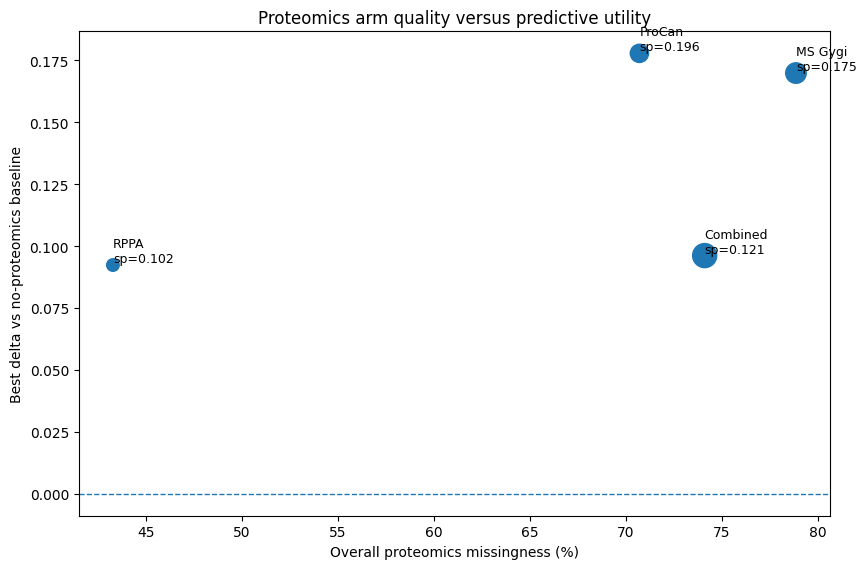

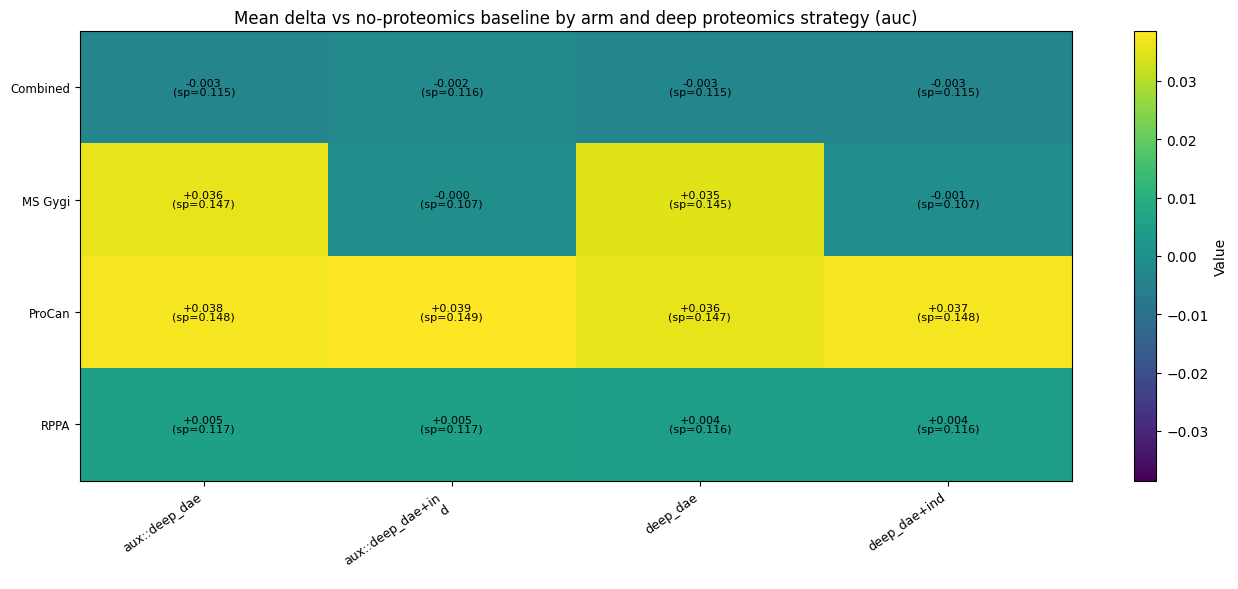

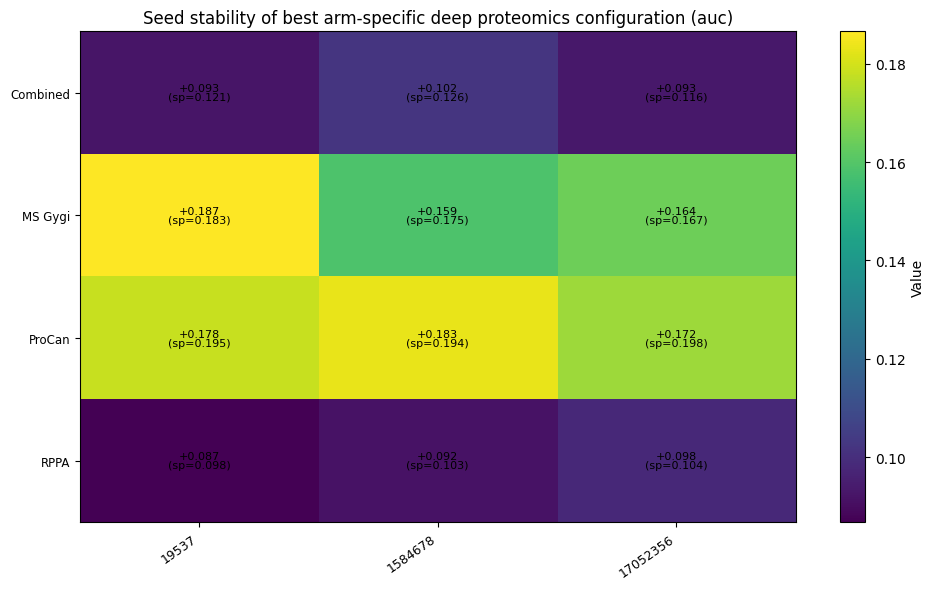

,drug,best_arm,model,feature_set,best_imputer,ranking_quality_spearman,fit_accuracy_r2,uplift_vs_no_prot,spearman_sd_across_seeds
81,SEPANTRONIUM BROMIDE (BRD:BRD-K76703230-004-04-1),ProCan,extratrees,rna+mut+prot,deep_dae+ind,0.488376,0.100446,0.078724,0.017653
96,VERUBULIN (BRD:BRD-K42673188-001-01-1),MS Gygi,extratrees,rna+cnv+prot,deep_dae,0.481641,0.060501,0.010222,0.011537
88,TOPOTECAN (BRD:BRD-K55696337-003-24-4),MS Gygi,extratrees,mut+prot,deep_dae,0.471647,0.028022,0.404609,0.022122
25,CYT-997 (BRD:BRD-K23363278-001-02-1),ProCan,extratrees,rna+prot,deep_dae,0.469254,0.074040,0.137993,0.005704
72,PU-H71 (BRD:BRD-K36529613-001-02-6),MS Gygi,elasticnet,prot,aux::deep_dae,0.468796,0.113314,NaN,0.018337
95,VELBAN (BRD:BRD-K06519765-065-01-6),Combined,extratrees,rna+cnv+prot,deep_dae+ind,0.457822,0.041648,-0.016561,0.008094
13,BNC105 (BRD:BRD-K20468903-001-01-6),ProCan,extratrees,rna+prot,aux::deep_dae,0.456050,0.064737,0.047984,0.018229
3,ANGUIDINE (BRD:BRD-K45724504-001-01-6),ProCan,elasticnet,rna+prot,aux::deep_dae,0.453129,0.092007,-0.028701,0.014115
27,DANUSERTIB (BRD:BRD-K07881437-001-04-6),MS Gygi,extratrees,cnv+prot,aux::deep_dae,0.439145,0.010665,0.135354,0.023328
15,BRUCEANTIN (BRD:BRD-A36057565-001-01-0),ProCan,extratrees,rna+prot,aux::deep_dae,0.429238,0.011301,0.012007,0.010991


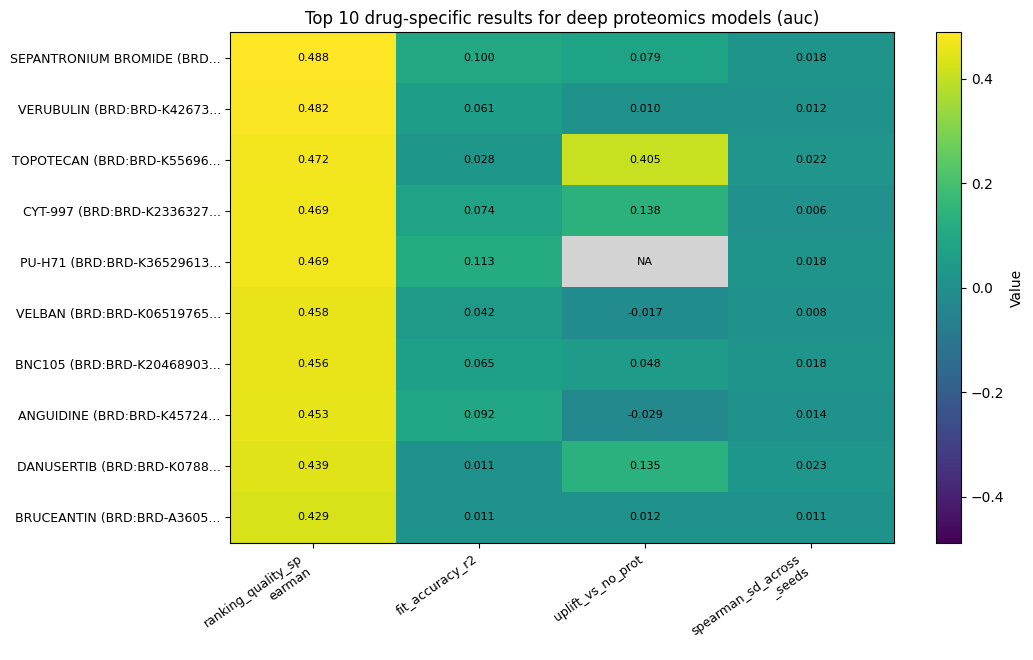

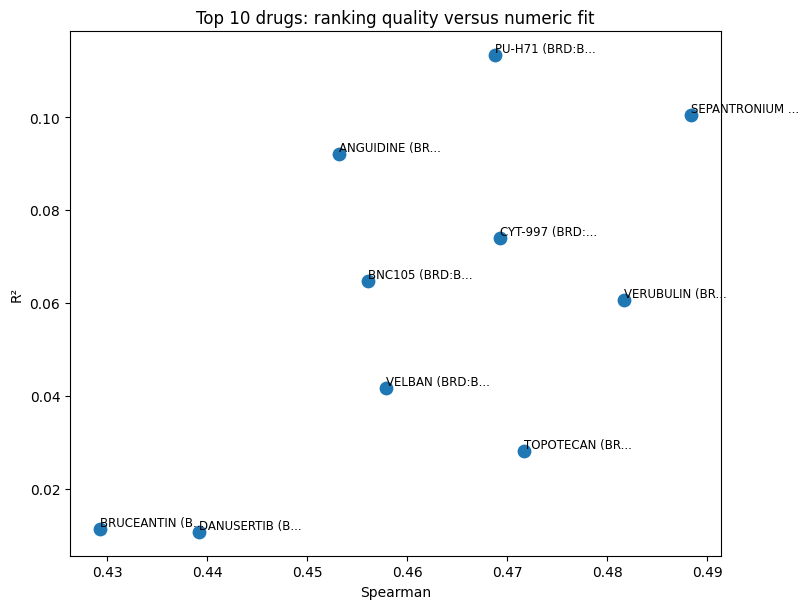

,metric,max_abs_diff,mean_abs_diff,n_rows_compared,n_rows_diff_gt_1e_12
0,mean_spearman,0.0,0.0,96,0
1,delta_vs_baseline,0.0,0.0,84,0


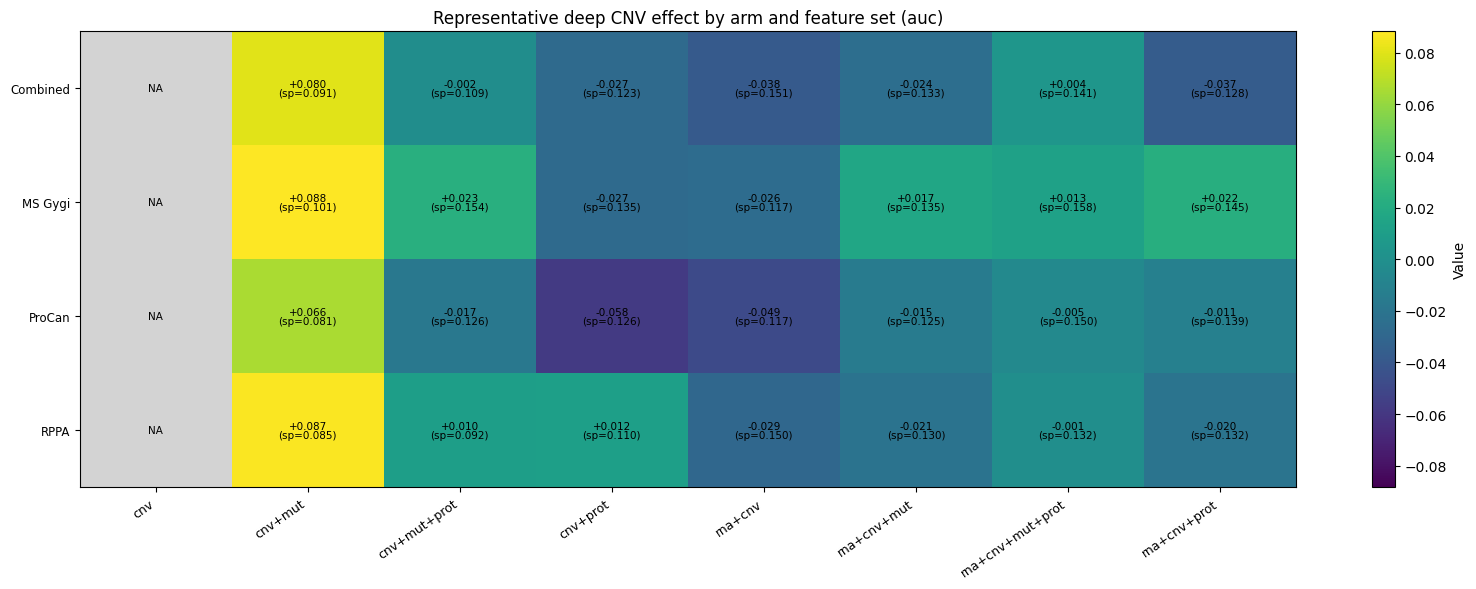

,artefact,path
0,deep_proteomics_detail_csv,artifacts/reports/notebook 5/deep_impute_bakeo...
1,deep_proteomics_summary_csv,artifacts/reports/notebook 5/deep_impute_bakeo...
2,deep_proteomics_per_seed_summary_csv,artifacts/reports/notebook 5/deep_impute_bakeo...
3,deep_cnv_detail_csv,artifacts/reports/notebook 5/deep_cnv_impute_b...
4,deep_cnv_summary_csv,artifacts/reports/notebook 5/deep_cnv_impute_b...
5,missingness_report_json,artifacts/reports/notebook 5/missingness_repor...
6,deep_proteomics_lock_json,artifacts/metadata/notebook 5/deep_imputer_cho...
7,deep_cnv_lock_json,artifacts/metadata/notebook 5/deep_imputer_cho...
8,best_deep_imputer_by_config_csv,artifacts/reports/notebook 5/best_deep_imputer...
9,best_deep_imputer_by_arm_csv,artifacts/reports/notebook 5/best_deep_imputer...


Artefact index written: artifacts/reports/notebook 5/artefact_index.json


In [ ]:
FIG_DIR = OUT_REPORTS / "figures"
INTERP_DIR = OUT_REPORTS / "interpretability"
FIG_DIR.mkdir(parents=True, exist_ok=True)
INTERP_DIR.mkdir(parents=True, exist_ok=True)

print("Saving evaluation figures to:", FIG_DIR)
print("Saving interpretability outputs to:", INTERP_DIR)

def safe_filename(s: str) -> str:
    return (
        str(s)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace("+", "plus")
        .replace(":", "_")
        .replace("|", "_")
    )

def wrap_label(s: str, width: int = 24) -> str:
    return "\n".join(textwrap.wrap(str(s), width=width))

def finish_plot(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()
    plt.close()

def draw_metric_heatmap(
    mat: pd.DataFrame,
    title: str,
    out_path: Path,
    centre_zero: bool = False,
    annotate_fmt: str = "{:.3f}",
    na_label: str = "NA",
    cmap_name: str = "viridis",
):
    if mat is None or mat.empty:
        print(f"[skip] {title}: empty matrix")
        return

    arr = mat.to_numpy(dtype=float)
    finite = np.isfinite(arr)
    if not finite.any():
        print(f"[skip] {title}: no finite values")
        return

    vmin = float(np.nanmin(arr))
    vmax = float(np.nanmax(arr))

    masked = np.ma.masked_invalid(arr)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad(color="lightgrey")

    plt.figure(figsize=(10.8, max(5.5, 0.55 * mat.shape[0] + 1.2)))

    if centre_zero and (vmin < 0.0) and (vmax > 0.0):
        vmax_abs = max(abs(vmin), abs(vmax))
        norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0.0, vmax=vmax_abs)
        im = plt.imshow(masked, aspect="auto", cmap=cmap, norm=norm)
    else:
        im = plt.imshow(masked, aspect="auto", cmap=cmap)

    plt.colorbar(im, label="Value")

    plt.xticks(
        range(mat.shape[1]),
        [wrap_label(c, 18) for c in mat.columns],
        rotation=35,
        ha="right",
        fontsize=9,
    )
    plt.yticks(
        range(mat.shape[0]),
        [wrap_label(i, 34) for i in mat.index],
        fontsize=9,
    )

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = arr[i, j]
            txt = na_label if not np.isfinite(val) else annotate_fmt.format(val)
            plt.text(j, i, txt, ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=170, bbox_inches="tight")
    plt.show()
    plt.close()

def draw_matrix_heatmap(
    mat: pd.DataFrame,
    title: str,
    out_path: Path,
    centre_zero: bool = False,
    annotate_fmt: str = "{:.3f}",
    extra_annot: Optional[pd.DataFrame] = None,
    row_label_width: int = 28,
    col_label_width: int = 18,
    row_height: float = 0.34,
    col_width: float = 1.8,
    min_width: float = 12.0,
    max_width: float = 18.0,
    annot_fontsize: float = 8.0,
    max_annot_rows: int = 24,
    na_label: str = "NA",
    cmap_name: str = "viridis",
):
    if mat is None or mat.empty:
        print(f"[skip] {title}: empty matrix")
        return

    arr = mat.to_numpy(dtype=float)
    finite = np.isfinite(arr)
    if not finite.any():
        print(f"[skip] {title}: no finite values")
        return

    vmin = float(np.nanmin(arr))
    vmax = float(np.nanmax(arr))

    fig_w = min(max_width, max(min_width, 5.8 + col_width * mat.shape[1]))
    fig_h = max(6.0, 1.8 + row_height * mat.shape[0])

    masked = np.ma.masked_invalid(arr)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad(color="lightgrey")

    plt.figure(figsize=(fig_w, fig_h))

    if centre_zero and (vmin < 0.0) and (vmax > 0.0):
        vmax_abs = max(abs(vmin), abs(vmax))
        norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0.0, vmax=vmax_abs)
        im = plt.imshow(masked, aspect="auto", cmap=cmap, norm=norm)
    else:
        im = plt.imshow(masked, aspect="auto", cmap=cmap)

    plt.colorbar(im, label="Value")
    plt.xticks(
        range(mat.shape[1]),
        [wrap_label(c, col_label_width) for c in mat.columns],
        rotation=35,
        ha="right",
        fontsize=9,
    )
    plt.yticks(
        range(mat.shape[0]),
        [wrap_label(i, row_label_width) for i in mat.index],
        fontsize=8.5,
    )
    plt.title(title)

    if mat.shape[0] <= max_annot_rows:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = arr[i, j]
                if not np.isfinite(val):
                    txt = na_label
                else:
                    txt = annotate_fmt.format(val)
                    if extra_annot is not None:
                        ev = extra_annot.iloc[i, j]
                        if pd.notna(ev):
                            txt = f"{txt}\n({ev})"
                plt.text(
                    j,
                    i,
                    txt,
                    ha="center",
                    va="center",
                    fontsize=annot_fontsize,
                    linespacing=0.9,
                )

    plt.subplots_adjust(left=0.43, bottom=0.18, right=0.94, top=0.90)
    finish_plot(out_path)

def short_arm_name(s: str) -> str:
    mapping = {
        "prot_combined_union": "Combined",
        "prot_procan_depmapSanger": "ProCan",
        "prot_rppa_ccle": "RPPA",
        "prot_ms_ccle_gygi": "MS Gygi",
    }
    return mapping.get(str(s), str(s))

def short_imputer_name(s: str) -> str:
    s = str(s)
    s = s.replace("deep_aux_rna_cnv_mut::", "aux::")
    s = s.replace("deep_dae+indicators", "deep_dae+ind")
    s = s.replace("deep_cnv_dae+indicators", "deep_cnv_dae+ind")
    s = s.replace("reference_without_prot", "ref_no_prot")
    s = s.replace("reference_without_cnv", "ref_no_cnv")
    s = s.replace("no_prot_reference", "no_prot_ref")
    return s

def short_compound_name(s: str, max_len: int = 36) -> str:
    s = str(s)
    return s if len(s) <= max_len else s[: max_len - 3] + "..."

def config_label_from_cols(df: pd.DataFrame) -> pd.Series:
    rank = pd.to_numeric(df["config_rank"], errors="coerce").fillna(-1).astype(int).astype(str)
    return (
        "r" + rank
        + " | " + df["arm"].map(short_arm_name).astype(str)
        + " | " + df["model"].astype(str)
        + " | " + df["feature_set"].astype(str)
    )

def select_top_heatmap_rows(
    mat: pd.DataFrame,
    extra_annot: Optional[pd.DataFrame] = None,
    max_rows: int = 24,
) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:
    if mat.shape[0] <= max_rows:
        return mat, extra_annot

    row_score = mat.abs().max(axis=1).sort_values(ascending=False)
    keep = row_score.head(max_rows).index.tolist()

    mat_sel = mat.loc[keep]
    extra_sel = extra_annot.loc[keep] if extra_annot is not None else None
    return mat_sel, extra_sel

def safe_mean(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(x.mean()) if x.size else np.nan

def safe_median(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if x.size else np.nan

def safe_std(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(x.std()) if x.size else np.nan

prot_summary_all = bakeoff_summary.copy()
prot_detail_all = bakeoff_df.copy()
cnv_summary_all = cnv_summary.copy() if "cnv_summary" in globals() else pd.DataFrame()
cnv_detail_all = cnv_bakeoff_df.copy() if "cnv_bakeoff_df" in globals() else pd.DataFrame()

for df_ in [prot_summary_all, prot_detail_all, cnv_summary_all, cnv_detail_all]:
    if df_.shape[0] > 0:
        for c in [
            "seed", "config_rank", "fold", "mean_spearman", "median_spearman",
            "std_spearman", "mean_r2", "delta_vs_baseline", "spearman", "r2",
            "n_train", "n_test"
        ]:
            if c in df_.columns:
                df_[c] = pd.to_numeric(df_[c], errors="coerce")

if "uses_prot" in prot_summary_all.columns:
    prot_summary_all["uses_prot"] = prot_summary_all["uses_prot"].astype(str).str.lower().eq("true")
if "uses_prot" in prot_detail_all.columns:
    prot_detail_all["uses_prot"] = prot_detail_all["uses_prot"].astype(str).str.lower().eq("true")

ref_prot_strategies = {"no_prot_reference", "reference_without_prot"}

# Proteomics best-by-config and best-by-arm summaries

prot_only_summary = prot_summary_all[
    (prot_summary_all["uses_prot"] == True)
    & (~prot_summary_all["imputer_strategy"].isin(ref_prot_strategies))
].copy()

best_imputer_by_config = (
    prot_only_summary
    .sort_values(
        ["config_rank", "delta_vs_baseline", "mean_spearman", "median_spearman"],
        ascending=[True, False, False, False],
    )
    .groupby(["config_rank", "arm", "model", "feature_set"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

# Only add baseline_mean_spearman if it is not already present
if "baseline_mean_spearman" not in best_imputer_by_config.columns:
    baseline_cfg = prot_summary_all[
        prot_summary_all["imputer_strategy"] == "reference_without_prot"
    ][["config_rank", "arm", "model", "feature_set", "mean_spearman"]].rename(
        columns={"mean_spearman": "baseline_mean_spearman"}
    )

    best_imputer_by_config = best_imputer_by_config.merge(
        baseline_cfg,
        on=["config_rank", "arm", "model", "feature_set"],
        how="left",
    )

best_imputer_by_config["config_label"] = config_label_from_cols(best_imputer_by_config)
best_imputer_by_config["imputer_short"] = best_imputer_by_config["imputer_strategy"].map(short_imputer_name)
best_imputer_by_config.to_csv(OUT_REPORTS / "best_deep_imputer_by_config.csv", index=False)
display(best_imputer_by_config.head(20))

best_by_arm = (
    best_imputer_by_config
    .sort_values(
        ["arm", "delta_vs_baseline", "mean_spearman", "median_spearman"],
        ascending=[True, False, False, False],
    )
    .groupby("arm", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
best_by_arm["arm_short"] = best_by_arm["arm"].map(short_arm_name)
best_by_arm.to_csv(OUT_REPORTS / "best_deep_imputer_by_arm.csv", index=False)
display(best_by_arm)

# Proteomics quality vs utility frontier

if isinstance(feat_miss_df, pd.DataFrame) and feat_miss_df.shape[0] > 0 and best_by_arm.shape[0] > 0:
    frontier_df = feat_miss_df.merge(
        best_by_arm[
            [
                "arm",
                "imputer_strategy",
                "model",
                "feature_set",
                "mean_spearman",
                "delta_vs_baseline",
                "baseline_mean_spearman",
            ]
        ],
        on="arm",
        how="left",
    )
    frontier_df["arm_short"] = frontier_df["arm"].map(short_arm_name)
    frontier_df.to_csv(OUT_REPORTS / "deep_quality_utility_frontier.csv", index=False)
    display(frontier_df)

    plt.figure(figsize=(8.8, 5.8))
    sizes = 80 + 220 * (frontier_df["n_features"] / frontier_df["n_features"].max())
    plt.scatter(
        frontier_df["overall_missing_pct"],
        frontier_df["delta_vs_baseline"],
        s=sizes,
    )
    plt.axhline(0.0, linestyle="--", linewidth=1.0)

    for _, r in frontier_df.iterrows():
        if pd.notna(r["delta_vs_baseline"]):
            plt.text(
                r["overall_missing_pct"],
                r["delta_vs_baseline"],
                f"{r['arm_short']}\nsp={r['mean_spearman']:.3f}",
                fontsize=9,
                ha="left",
                va="bottom",
            )

    plt.title("Proteomics arm quality versus predictive utility")
    plt.xlabel("Overall proteomics missingness (%)")
    plt.ylabel("Best delta vs no-proteomics baseline")
    finish_plot(FIG_DIR / "deep_quality_utility_frontier.png")

# Proteomics arm x strategy heatmap

if prot_only_summary.shape[0] > 0:
    arm_strategy = (
        prot_only_summary
        .groupby(["arm", "imputer_strategy"], as_index=False)
        .agg(
            mean_delta=("delta_vs_baseline", safe_mean),
            mean_spearman=("mean_spearman", safe_mean),
            n_configs=("config_rank", "nunique"),
        )
    )

    arm_strategy["arm_label"] = arm_strategy["arm"].map(short_arm_name)
    arm_strategy["imp_label"] = arm_strategy["imputer_strategy"].map(short_imputer_name)
    arm_strategy.to_csv(OUT_REPORTS / "deep_proteomics_arm_strategy_summary.csv", index=False)

    hm_arm = arm_strategy.pivot(index="arm_label", columns="imp_label", values="mean_delta")
    ann_arm = (
        arm_strategy.assign(
            lbl=arm_strategy["mean_spearman"].map(lambda x: f"sp={x:.3f}" if pd.notna(x) else "")
        )
        .pivot(index="arm_label", columns="imp_label", values="lbl")
        .reindex(index=hm_arm.index, columns=hm_arm.columns)
    )

    draw_matrix_heatmap(
        hm_arm,
        title=f"Mean delta vs no-proteomics baseline by arm and deep proteomics strategy ({PRIMARY_TARGET})",
        out_path=FIG_DIR / f"deep_proteomics_arm_strategy_heatmap_{PRIMARY_TARGET}.png",
        centre_zero=True,
        annotate_fmt="{:+.3f}",
        extra_annot=ann_arm,
        row_label_width=18,
        col_label_width=16,
        row_height=0.55,
        col_width=1.9,
        min_width=10.0,
        max_width=14.5,
        annot_fontsize=8.0,
        max_annot_rows=12,
    )

# Seed stability for best config in each arm

if best_by_arm.shape[0] > 0 and isinstance(per_seed_summary, pd.DataFrame) and per_seed_summary.shape[0] > 0:
    per_seed_best = per_seed_summary.merge(
        best_by_arm[
            ["config_rank", "arm", "model", "feature_set", "imputer_strategy"]
        ],
        on=["config_rank", "arm", "model", "feature_set", "imputer_strategy"],
        how="inner",
    )

    per_seed_base = per_seed_summary[
        per_seed_summary["imputer_strategy"] == "reference_without_prot"
    ][["seed", "config_rank", "arm", "model", "feature_set", "mean_spearman"]].rename(
        columns={"mean_spearman": "baseline_mean_spearman"}
    )

    seed_delta = per_seed_best.merge(
        per_seed_base,
        on=["seed", "config_rank", "arm", "model", "feature_set"],
        how="left",
    )
    seed_delta["delta_vs_baseline"] = seed_delta["mean_spearman"] - seed_delta["baseline_mean_spearman"]
    seed_delta["arm_label"] = seed_delta["arm"].map(short_arm_name)
    seed_delta.to_csv(OUT_REPORTS / "deep_seed_stability_best_by_arm.csv", index=False)

    hm_seed = seed_delta.pivot(index="arm_label", columns="seed", values="delta_vs_baseline")
    ann_seed = (
        seed_delta.assign(
            lbl=seed_delta["mean_spearman"].map(lambda x: f"sp={x:.3f}" if pd.notna(x) else "")
        )
        .pivot(index="arm_label", columns="seed", values="lbl")
        .reindex(index=hm_seed.index, columns=hm_seed.columns)
    )

    draw_matrix_heatmap(
        hm_seed,
        title=f"Seed stability of best arm-specific deep proteomics configuration ({PRIMARY_TARGET})",
        out_path=FIG_DIR / f"deep_seed_stability_best_by_arm_{PRIMARY_TARGET}.png",
        centre_zero=True,
        annotate_fmt="{:+.3f}",
        extra_annot=ann_seed,
        row_label_width=18,
        col_label_width=10,
        row_height=0.55,
        col_width=1.4,
        min_width=7.5,
        max_width=10.5,
        annot_fontsize=8.0,
        max_annot_rows=10,
    )

# Top 10 best-performing drugs
# Spearman = ranking quality
# R² = numeric fit / accuracy

if prot_detail_all.shape[0] > 0:
    prot_drug_means = (
        prot_detail_all
        .groupby(
            ["seed", "config_rank", "arm", "model", "feature_set", "imputer_strategy", "compound_id"],
            as_index=False,
        )
        .agg(
            spearman=("spearman", safe_mean),
            r2=("r2", safe_mean),
        )
    )

    prot_ref = (
        prot_drug_means[prot_drug_means["imputer_strategy"] == "reference_without_prot"][
            ["seed", "config_rank", "arm", "model", "feature_set", "compound_id", "spearman"]
        ]
        .rename(columns={"spearman": "baseline_spearman"})
    )

    prot_imputed = prot_drug_means[
        ~prot_drug_means["imputer_strategy"].isin(ref_prot_strategies)
    ].copy()

    prot_imputed = prot_imputed.merge(
        prot_ref,
        on=["seed", "config_rank", "arm", "model", "feature_set", "compound_id"],
        how="left",
    )
    prot_imputed["delta_vs_baseline"] = prot_imputed["spearman"] - prot_imputed["baseline_spearman"]

    prot_drug_across_seeds = (
        prot_imputed
        .groupby(
            ["config_rank", "arm", "model", "feature_set", "imputer_strategy", "compound_id"],
            as_index=False,
        )
        .agg(
            mean_spearman=("spearman", safe_mean),
            median_spearman=("spearman", safe_median),
            std_spearman=("spearman", safe_std),
            mean_r2=("r2", safe_mean),
            mean_delta_vs_baseline=("delta_vs_baseline", safe_mean),
            n_seeds=("compound_id", "count"),
        )
    )

    best_per_drug = (
        prot_drug_across_seeds
        .sort_values(
            ["compound_id", "mean_spearman", "mean_r2", "mean_delta_vs_baseline"],
            ascending=[True, False, False, False],
        )
        .groupby("compound_id", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    top10_drugs = (
        best_per_drug
        .sort_values(
            ["mean_spearman", "mean_r2", "mean_delta_vs_baseline"],
            ascending=[False, False, False],
        )
        .head(10)
        .copy()
    )

    top10_drugs["arm_short"] = top10_drugs["arm"].map(short_arm_name)
    top10_drugs["imputer_short"] = top10_drugs["imputer_strategy"].map(short_imputer_name)

    top10_drugs_report = top10_drugs[
        [
            "compound_id",
            "arm_short",
            "model",
            "feature_set",
            "imputer_short",
            "mean_spearman",
            "mean_r2",
            "mean_delta_vs_baseline",
            "std_spearman",
        ]
    ].rename(
        columns={
            "compound_id": "drug",
            "arm_short": "best_arm",
            "imputer_short": "best_imputer",
            "mean_spearman": "ranking_quality_spearman",
            "mean_r2": "fit_accuracy_r2",
            "mean_delta_vs_baseline": "uplift_vs_no_prot",
            "std_spearman": "spearman_sd_across_seeds",
        }
    )

    top10_drugs_report.to_csv(OUT_REPORTS / "top10_best_drugs_deep_proteomics.csv", index=False)
    display(top10_drugs_report)

    top10_metric_mat = (
        top10_drugs_report.assign(
            drug_short=top10_drugs_report["drug"].map(lambda x: short_compound_name(x, 28))
        )
        .set_index("drug_short")[
            [
                "ranking_quality_spearman",
                "fit_accuracy_r2",
                "uplift_vs_no_prot",
                "spearman_sd_across_seeds",
            ]
        ]
        .copy()
    )

    draw_metric_heatmap(
        mat=top10_metric_mat,
        title=f"Top 10 drug-specific results for deep proteomics models ({PRIMARY_TARGET})",
        out_path=FIG_DIR / f"top10_drug_metrics_deep_proteomics_{PRIMARY_TARGET}.png",
        centre_zero=True,
        annotate_fmt="{:.3f}",
        na_label="NA",
        cmap_name="viridis",
    )

    plt.figure(figsize=(8.2, 6.2))
    plt.scatter(
        top10_drugs_report["ranking_quality_spearman"],
        top10_drugs_report["fit_accuracy_r2"],
        s=80,
    )
    for _, r in top10_drugs_report.iterrows():
        plt.text(
            r["ranking_quality_spearman"],
            r["fit_accuracy_r2"],
            short_compound_name(r["drug"], 16),
            fontsize=8.5,
            ha="left",
            va="bottom",
        )
    plt.title("Top 10 drugs: ranking quality versus numeric fit")
    plt.xlabel("Spearman")
    plt.ylabel("R²")
    finish_plot(FIG_DIR / "top10_drugs_spearman_vs_r2.png")

# CNV strategy equivalence check

if cnv_summary_all.shape[0] > 0:
    cnv_equiv_rows = []

    for metric in ["mean_spearman", "delta_vs_baseline"]:
        pivot = cnv_summary_all.pivot_table(
            index=["config_rank", "arm", "model", "feature_set"],
            columns="imputer_strategy",
            values=metric,
            aggfunc="first",
        )

        if ("cnv::deep_cnv_dae" in pivot.columns) and ("cnv::deep_cnv_dae+indicators" in pivot.columns):
            diff = (
                pd.to_numeric(pivot["cnv::deep_cnv_dae"], errors="coerce")
                - pd.to_numeric(pivot["cnv::deep_cnv_dae+indicators"], errors="coerce")
            ).abs()

            cnv_equiv_rows.append({
                "metric": metric,
                "max_abs_diff": float(diff.max()) if diff.notna().any() else np.nan,
                "mean_abs_diff": float(diff.mean()) if diff.notna().any() else np.nan,
                "n_rows_compared": int(diff.notna().sum()),
                "n_rows_diff_gt_1e_12": int((diff > 1e-12).sum()) if diff.notna().any() else 0,
            })

    cnv_equiv_df = pd.DataFrame(cnv_equiv_rows)
    cnv_equiv_df.to_csv(OUT_REPORTS / "deep_cnv_strategy_equivalence_check.csv", index=False)
    display(cnv_equiv_df)

    # If both strategies are effectively identical, keep only the plain version for plots
    cnv_plot_df = cnv_summary_all.copy()
    if (
        cnv_equiv_df.shape[0] > 0
        and cnv_equiv_df["n_rows_diff_gt_1e_12"].fillna(0).sum() == 0
    ):
        cnv_plot_df = cnv_plot_df[cnv_plot_df["imputer_strategy"] == "cnv::deep_cnv_dae"].copy()

    cnv_arm_feature = (
        cnv_plot_df[
            cnv_plot_df["imputer_strategy"].isin(["cnv::deep_cnv_dae", "cnv::deep_cnv_dae+indicators"])
        ]
        .groupby(["arm", "feature_set"], as_index=False)
        .agg(
            mean_delta=("delta_vs_baseline", safe_mean),
            mean_spearman=("mean_spearman", safe_mean),
        )
    )

    if cnv_arm_feature.shape[0] > 0:
        cnv_arm_feature["arm_label"] = cnv_arm_feature["arm"].map(short_arm_name)
        cnv_arm_feature.to_csv(OUT_REPORTS / "deep_cnv_arm_feature_summary.csv", index=False)

        hm_cnv = cnv_arm_feature.pivot(index="arm_label", columns="feature_set", values="mean_delta")
        ann_cnv = (
            cnv_arm_feature.assign(
                lbl=cnv_arm_feature["mean_spearman"].map(lambda x: f"sp={x:.3f}" if pd.notna(x) else "")
            )
            .pivot(index="arm_label", columns="feature_set", values="lbl")
            .reindex(index=hm_cnv.index, columns=hm_cnv.columns)
        )

        hm_cnv_plot, ann_cnv_plot = select_top_heatmap_rows(hm_cnv, ann_cnv, max_rows=8)

        draw_matrix_heatmap(
            hm_cnv_plot,
            title=f"Representative deep CNV effect by arm and feature set ({PRIMARY_TARGET})",
            out_path=FIG_DIR / f"deep_cnv_arm_feature_heatmap_{PRIMARY_TARGET}.png",
            centre_zero=True,
            annotate_fmt="{:+.3f}",
            extra_annot=ann_cnv_plot,
            row_label_width=18,
            col_label_width=16,
            row_height=0.55,
            col_width=1.3,
            min_width=12.0,
            max_width=17.0,
            annot_fontsize=7.5,
            max_annot_rows=10,
        )
artefact_index = {
    "deep_proteomics_detail_csv": str(merged_path),
    "deep_proteomics_summary_csv": str(summary_path),
    "deep_proteomics_per_seed_summary_csv": str(per_seed_path),
    "deep_cnv_detail_csv": str(cnv_merged_path),
    "deep_cnv_summary_csv": str(cnv_summary_path),
    "missingness_report_json": str(report_path),
    "deep_proteomics_lock_json": str(prot_deep_choice_path),
    "deep_cnv_lock_json": str(cnv_deep_choice_path),
    "best_deep_imputer_by_config_csv": str(OUT_REPORTS / "best_deep_imputer_by_config.csv"),
    "best_deep_imputer_by_arm_csv": str(OUT_REPORTS / "best_deep_imputer_by_arm.csv"),
    "deep_quality_utility_frontier_csv": str(OUT_REPORTS / "deep_quality_utility_frontier.csv"),
    "deep_seed_stability_best_by_arm_csv": str(OUT_REPORTS / "deep_seed_stability_best_by_arm.csv"),
    "top10_best_drugs_deep_proteomics_csv": str(OUT_REPORTS / "top10_best_drugs_deep_proteomics.csv"),
    "deep_cnv_strategy_equivalence_check_csv": str(OUT_REPORTS / "deep_cnv_strategy_equivalence_check.csv"),
    "figures_dir": str(FIG_DIR),
    "interpretability_dir": str(INTERP_DIR),
}

write_json(artefact_index, OUT_REPORTS / "artefact_index.json")
display(pd.DataFrame({"artefact": list(artefact_index.keys()), "path": list(artefact_index.values())}))
print("Artefact index written:", OUT_REPORTS / "artefact_index.json")

# EDA interpretation 

The  EDA for Notebook 5 shows that deep proteomics imputation improves predictive performance in a clearly arm-dependent way rather than uniformly across all proteomics sources. The strongest overall pattern is that **ProCan** and **MS Gygi** derive the most meaningful benefit from deep reconstruction, whereas **RPPA** remains comparatively weak and the **combined union** arm remains inconsistent despite the use of deeper imputers. This is evident in the arm-level quality versus predictive utility plot, where ProCan achieves the highest best delta over its matched no-proteomics baseline, followed closely by MS Gygi. By contrast, the combined union arm shows only moderate utility despite its large feature space, and RPPA remains the least useful arm overall. Taken together, this suggests that biological informativeness of the proteomics backbone is more important than simply maximising feature count or reducing apparent missingness.

The heatmap of mean delta versus the matched no-proteomics baseline reinforces this interpretation. For **ProCan**, all deep proteomics strategies are consistently positive, with average gains around +0.036 to +0.039. This indicates that ProCan is robust to the specific deep imputation variant and contributes genuine complementary signal once reconstructed. **MS Gygi** also shows positive effects, particularly for standard and auxiliary deep DAE variants, with mean gains around +0.035 to +0.036 in the best arm-level summary. **RPPA** produces only small positive gains, roughly +0.004 to +0.005, so deep imputation does not materially alter its status as a weak comparator arm. The **combined union** arm is the least convincing, with slightly negative average deltas across the arm-level summary. This means that deep reconstruction cannot fully compensate for the structural heterogeneity and platform-driven sparsity of the union representation.

The seed-stability heatmap shows that these findings are stable across all three seeds rather than arising from a favourable split. **ProCan** remains strong in every seed, with best arm-specific deep configurations producing mean Spearman values around 0.194 to 0.198 and deltas around +0.172 to +0.183. **MS Gygi** is also stable, with best deep configurations typically producing mean Spearman values around 0.167 to 0.183 and deltas around +0.159 to +0.187. **RPPA** and the **combined union** arm remain lower across seeds, although both still show some positive cases. This consistency strengthens the conclusion that ProCan is the most reliable arm for deep-imputation-based downstream modelling, with MS Gygi as a credible secondary option.

At the configuration level, the largest uplifts are concentrated in **mutation-plus-proteomics** settings. For elastic net, the best `mut+prot` configuration yields a delta of **+0.1778** for ProCan, **+0.1698** for MS Gygi, **+0.0961** for the combined union arm, and **+0.0923** for RPPA. These are large gains, but they should be interpreted with care because the matched mutation-only baselines are extremely weak. In other words, the delta is large partly because the non-proteomic comparator is poor. Even so, these results show that deep proteomics recovery can add substantial signal when proteomics is paired with otherwise weak modalities.

The more informative test is whether deep proteomics improves already competitive RNA-containing models. Here the results are more modest but also more convincing. For **ProCan extratrees**, `rna+prot` improves by **+0.0202**, `rna+cnv+prot` by **+0.0216**, `rna+mut+prot` by **+0.0252**, and `rna+cnv+mut+prot` by **+0.0270**. For **MS Gygi extratrees**, `rna+prot` improves by **+0.0279**, `rna+cnv+prot` by **+0.0180**, `rna+mut+prot` by **+0.0264**, and `rna+cnv+mut+prot` by **+0.0166**. These gains are smaller than the mutation-only uplifts, but they are scientifically more important because they show that deep-imputed proteomics can still help strong models built on RNA and other backbone modalities.

By contrast, the **combined union** arm continues to underperform in the strongest RNA-containing settings. For example, elastic net `rna+prot`, `rna+mut+prot`, and `rna+cnv+mut+prot` remain below their matched no-proteomics baselines, and similar negative deltas are also seen for several ridge and extratrees variants. This suggests that the union arm remains dominated by platform heterogeneity and structured missingness, even after deep imputation. It therefore remains more suitable as a robustness or stress-test arm than as a primary modelling backbone.

The **RPPA** arm shows a mixed but generally modest pattern. It can benefit in weaker settings such as `mut+prot` and some CNV-inclusive combinations, but in stronger RNA-based settings the improvements are either tiny or negative. For instance, elastic net `rna+prot` improves by only **+0.0012**, and elastic net `rna+mut+prot` by only **+0.0003**. This indicates that deep imputation does not fundamentally change the earlier interpretation from Notebook 3b and Notebook 4 that RPPA contributes limited additional signal beyond the transcriptomic backbone.

The drug-level summaries show that deep proteomics models can nevertheless achieve strong ranking performance for selected compounds. Several drugs, including **SEPANTRONIUM BROMIDE**, **VERUBULIN**, **TOPOTECAN**, **CYT-997**, **PU-H71**, and **VELBAN**, reach mean Spearman values around **0.43 to 0.49**, which is strong relative performance in this setting. However, the scatter of Spearman versus \(R^2\) shows that ranking quality and numeric fit do not always move together. Some drugs, such as **TOPOTECAN**, achieve excellent ranking but only modest \(R^2\), while others such as **PU-H71** and **SEPANTRONIUM BROMIDE** show somewhat better fit. This mirrors the pattern already observed in the earlier notebooks: the models are better at ordering cell lines by response than at accurately recovering the exact numerical AUC values.

The representative deep CNV heatmap shows that deep CNV imputation does not overturn the broader conclusion from Notebook 4. Some positive effects remain in restricted settings, particularly **`cnv+mut`**, where all arms show positive deltas. However, once CNV is added into stronger RNA-containing configurations, the effect is often negative, especially for **ProCan** and the **combined union** arm. This suggests that deep CNV reconstruction is still not consistently useful in the strongest modelling settings and that CNV remains a secondary or low-priority modality for the main downstream models.

When contrasted with **Notebook 3a**, the difference between endpoints remains clear. The LFC analyses showed weaker and less stable predictive behaviour overall, smaller and more inconsistent proteomics gains, and a noisier modelling landscape. Notebook 5, which operates in the AUC setting, continues to support the conclusion that **AUC is the more learnable and interpretable target**. The current deep-imputation results are much more coherent than the earlier LFC findings, and the arm hierarchy is more stable.

When contrasted with **Notebook 3b**, the main scientific ranking of proteomics arms is unchanged. **ProCan** remains the strongest arm overall, **MS Gygi** remains the best secondary arm, **RPPA** remains weak, and the **combined union** arm remains mainly useful as a robustness stress-test. What Notebook 5 adds is evidence that deep imputation can strengthen the useful arms further, especially ProCan and MS Gygi, and can recover additional proteomics value in several strong RNA-containing models.

When contrasted with **Notebook 4**, the main added value of Notebook 5 is that deep imputers are more effective than the shallow imputation schemes in recovering proteomics signal for the stronger arms. In Notebook 4, ProCan already looked promising and MS Gygi was secondary, but the gains were generally smaller and the combined union arm remained difficult to rescue. Notebook 5 shows that deep reconstruction improves the picture for ProCan and MS Gygi more clearly, especially in extratrees and some elastic net settings. However, it still does not rescue the union arm sufficiently to justify promoting it above ProCan or MS Gygi.

Overall, the final EDA for Notebook 5 supports four main conclusions. First, **deep proteomics imputation is genuinely beneficial for ProCan and MS Gygi**, particularly in extratrees and some elastic net configurations. Second, **ProCan remains the strongest overall arm** for downstream modelling, with the most stable and broadly positive gains. Third, **MS Gygi is a credible secondary arm** and benefits substantially from deep reconstruction in several settings. Fourth, **RPPA remains a weak comparator and the combined union arm remains unsuitable as a primary model arm**, even though selected niche configurations can still show positive uplift. These results therefore strengthen the case for carrying ProCan forward as the main deep-imputed proteomics backbone, keeping MS Gygi as a secondary comparison arm, and treating RPPA and combined union primarily as supporting or robustness analyses.